In [1]:
from IPython import get_ipython
get_ipython().run_line_magic("matplotlib", "inline") 
import matplotlib.pyplot as plt
import matplotlib
print(matplotlib.get_backend())  

inline


ERROR 1: PROJ: proj_create_from_database: Open of /projects/illinois/eng/cee/hmhorow/sjacker2/software/miniconda3/envs/climate/share/proj failed


Unique EPA monitors used: 2,175
Unique MERRA-2 grid cells containing monitors: 349


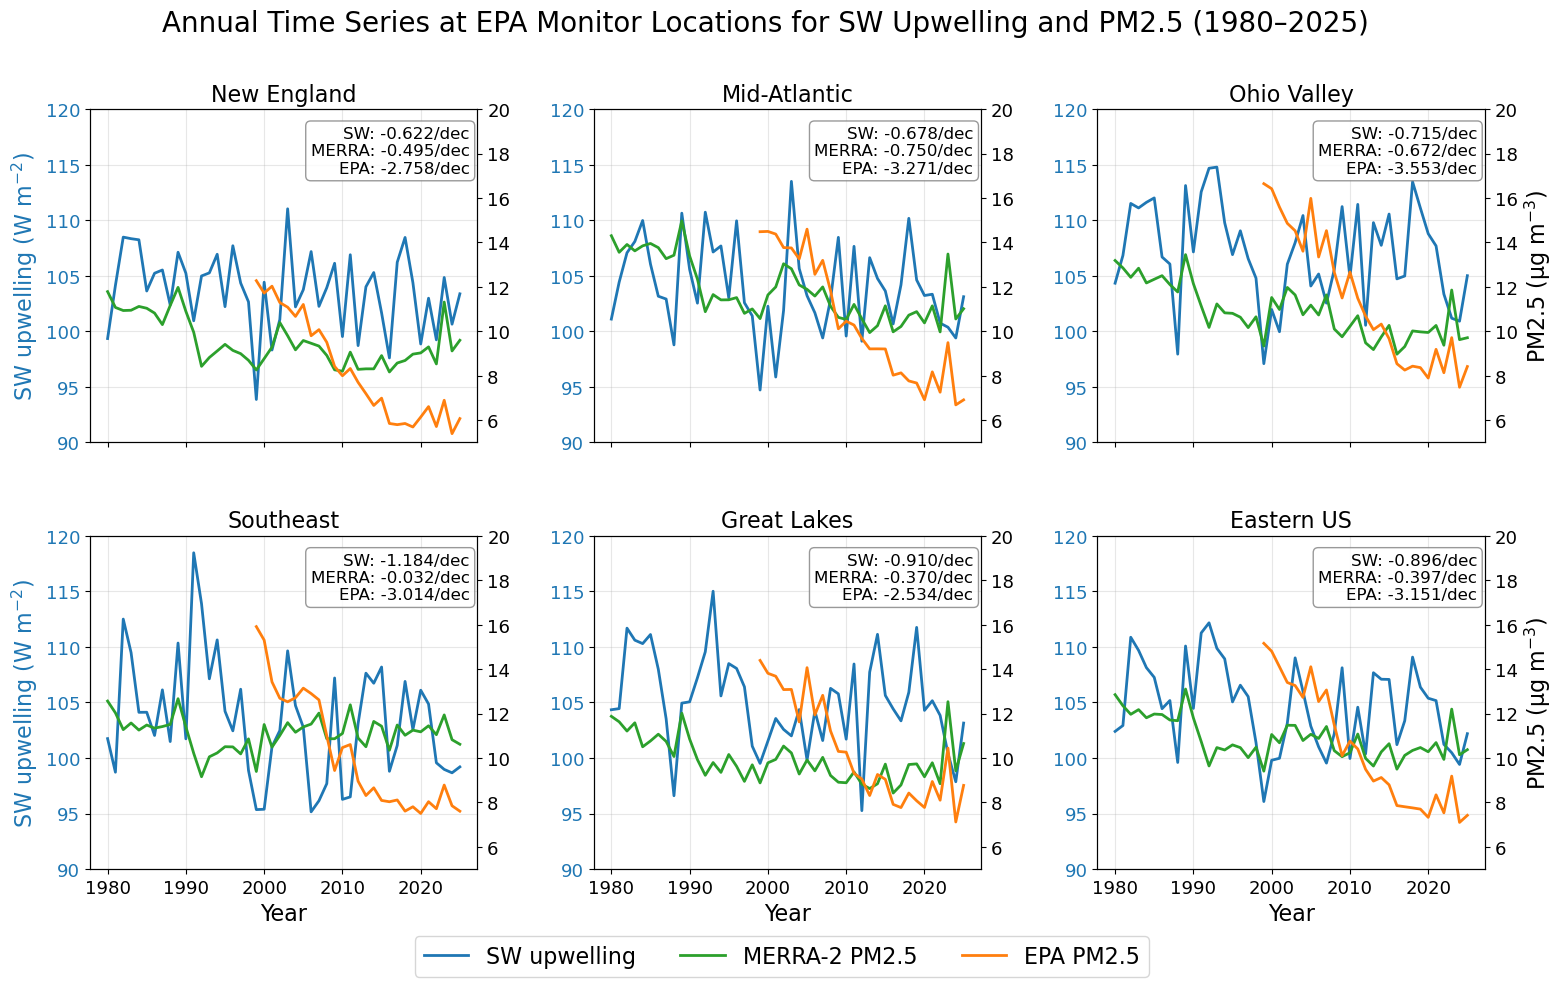

In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import geopandas as gpd

# -----------------------------
# File paths
# -----------------------------
flux_file = "/scratch/sjacker2/project_data/merra2_rad_downloads/merra2_toa_upwelling_lw_sw_combined.nc"
pm25_t2m_file = "/scratch/sjacker2/project_data/merra2_pm25_t2m_eastern_us_monthly_fields_DRY.nc"
monitor_file = "/scratch/sjacker2/project_data/monthly_pm25_eastern_us_1999_2025.csv"
states_shp = "/scratch/sjacker2/project_data/cb_2018_us_state_500k.shp"

# -----------------------------
# Region definitions
# -----------------------------
REGIONS = {
    "New England": [
        "Connecticut", "Maine", "Massachusetts", "New Hampshire", "Rhode Island", "Vermont"
    ],
    "Mid-Atlantic": [
        "New Jersey", "New York", "Pennsylvania", "Delaware", "Maryland", "Virginia"
    ],
    "Ohio Valley": [
        "Indiana", "Kentucky", "Ohio", "West Virginia", "Tennessee"
    ],
    "Southeast": [
        "Alabama", "Florida", "Georgia", "Mississippi",
        "North Carolina", "South Carolina", "Arkansas", "Louisiana", "Missouri"
    ],
    "Great Lakes": [
        "Michigan", "Wisconsin", "Illinois"
    ],
}

REGION_ORDER = [
    "New England",
    "Mid-Atlantic",
    "Ohio Valley",
    "Southeast",
    "Great Lakes",
]

PANEL_ORDER = REGION_ORDER + ["Eastern US"]

STATE_TO_REGION = {
    state: region for region, states in REGIONS.items() for state in states
}

STATE_ABBR_TO_NAME = {
    "AL": "Alabama", "AR": "Arkansas", "CT": "Connecticut", "DE": "Delaware",
    "FL": "Florida", "GA": "Georgia", "IL": "Illinois", "IN": "Indiana",
    "KY": "Kentucky", "LA": "Louisiana", "ME": "Maine", "MA": "Massachusetts",
    "MI": "Michigan", "MS": "Mississippi", "MO": "Missouri", "NH": "New Hampshire",
    "NJ": "New Jersey", "NY": "New York", "NC": "North Carolina", "OH": "Ohio",
    "OK": "Oklahoma", "PA": "Pennsylvania", "RI": "Rhode Island",
    "SC": "South Carolina", "TN": "Tennessee", "TX": "Texas", "VT": "Vermont",
    "VA": "Virginia", "WV": "West Virginia", "WI": "Wisconsin"
}

STATE_FIPS_TO_NAME = {
    1: "Alabama", 5: "Arkansas", 9: "Connecticut", 10: "Delaware",
    12: "Florida", 13: "Georgia", 17: "Illinois", 18: "Indiana",
    21: "Kentucky", 22: "Louisiana", 23: "Maine", 25: "Massachusetts",
    26: "Michigan", 28: "Mississippi", 29: "Missouri", 33: "New Hampshire",
    34: "New Jersey", 36: "New York", 37: "North Carolina", 39: "Ohio",
    40: "Oklahoma", 42: "Pennsylvania", 44: "Rhode Island", 45: "South Carolina",
    47: "Tennessee", 48: "Texas", 50: "Vermont", 51: "Virginia",
    54: "West Virginia", 55: "Wisconsin"
}

# -----------------------------
# Helpers
# -----------------------------
def load_us_states_gdf(shp_path):
    states = gpd.read_file(shp_path).to_crs("EPSG:4326")

    if "NAME" not in states.columns:
        raise ValueError("Could not find NAME column in state shapefile.")

    states = states[states["NAME"].isin(STATE_TO_REGION.keys())].copy()
    states["state_name"] = states["NAME"]
    states["region"] = states["state_name"].map(STATE_TO_REGION)

    return states[["state_name", "region", "geometry"]]


def build_region_masks(lon, lat, states_gdf):
    lon2d, lat2d = np.meshgrid(lon.values, lat.values)

    grid = gpd.GeoDataFrame(
        {"lon": lon2d.ravel(), "lat": lat2d.ravel()},
        geometry=gpd.points_from_xy(lon2d.ravel(), lat2d.ravel()),
        crs="EPSG:4326"
    )

    joined = gpd.sjoin(
        grid,
        states_gdf[["region", "geometry"]],
        how="left",
        predicate="within"
    )

    masks = {}

    for region in REGION_ORDER:
        mask = joined["region"].eq(region).values.reshape(len(lat), len(lon))
        masks[region] = xr.DataArray(
            mask,
            coords={"lat": lat, "lon": lon},
            dims=("lat", "lon")
        )

    eastern_mask = joined["region"].notna().values.reshape(len(lat), len(lon))
    masks["Eastern US"] = xr.DataArray(
        eastern_mask,
        coords={"lat": lat, "lon": lon},
        dims=("lat", "lon")
    )

    return masks


def get_edges_from_centers(centers):
    centers = np.asarray(centers)

    edges = np.zeros(len(centers) + 1)
    edges[1:-1] = 0.5 * (centers[:-1] + centers[1:])
    edges[0] = centers[0] - 0.5 * (centers[1] - centers[0])
    edges[-1] = centers[-1] + 0.5 * (centers[-1] - centers[-2])

    return edges


def assign_monitors_to_grid(monitors, lats, lons):
    lat_edges = get_edges_from_centers(lats)
    lon_edges = get_edges_from_centers(lons)

    lat_idx = np.digitize(monitors["Latitude"].values, lat_edges) - 1
    lon_idx = np.digitize(monitors["Longitude"].values, lon_edges) - 1

    monitors = monitors.copy()
    monitors["lat_idx"] = lat_idx
    monitors["lon_idx"] = lon_idx

    monitors = monitors[
        (monitors["lat_idx"] >= 0) &
        (monitors["lat_idx"] < len(lats)) &
        (monitors["lon_idx"] >= 0) &
        (monitors["lon_idx"] < len(lons))
    ].copy()

    monitors["grid_lat"] = lats[monitors["lat_idx"].values]
    monitors["grid_lon"] = lons[monitors["lon_idx"].values]

    return monitors


def build_monitor_cell_mask(lon, lat, monitor_df):
    lats = lat.values
    lons = lon.values

    mon_locs = (
        monitor_df[["monitor_id", "Latitude", "Longitude"]]
        .drop_duplicates()
        .reset_index(drop=True)
    )

    mon_for_grid = mon_locs.copy()

    if np.nanmax(lons) > 180:
        mon_for_grid["Longitude"] = mon_for_grid["Longitude"] % 360

    mon_grid = assign_monitors_to_grid(mon_for_grid, lats, lons)

    unique_cells = (
        mon_grid[["lat_idx", "lon_idx"]]
        .drop_duplicates()
        .reset_index(drop=True)
    )

    mask = xr.zeros_like(
        xr.DataArray(
            np.zeros((len(lat), len(lon)), dtype=bool),
            coords={"lat": lat, "lon": lon},
            dims=("lat", "lon")
        ),
        dtype=bool
    )

    for _, row in unique_cells.iterrows():
        mask.values[int(row["lat_idx"]), int(row["lon_idx"])] = True

    return mask, mon_grid, unique_cells


def regional_weighted_mean_timeseries(da_3d, combined_mask_2d):
    weights = np.cos(np.deg2rad(da_3d["lat"]))
    masked = da_3d.where(combined_mask_2d)
    return masked.weighted(weights).mean(dim=("lat", "lon"))


def annualize_xr_timeseries(ts):
    return ts.groupby("time.year").mean()


def fit_trend_line(years, values):
    years = np.asarray(years, dtype=float)
    values = np.asarray(values, dtype=float)

    mask = np.isfinite(years) & np.isfinite(values)

    if mask.sum() < 2:
        return np.full_like(years, np.nan, dtype=float), np.nan

    coeffs = np.polyfit(years[mask], values[mask], 1)
    trendline = np.polyval(coeffs, years)

    return trendline, coeffs[0] * 10.0


def detect_monitor_state_column(df):
    for col in ["state_name", "state", "State Name", "state_full"]:
        if col in df.columns:
            return col, "name"

    for col in ["state_abbr", "state_code", "state_postal", "State Code"]:
        if col in df.columns:
            return col, "abbr"

    for col in ["state_fips", "State FIPS", "STATEFP", "statefp"]:
        if col in df.columns:
            return col, "fips"

    return None, None


def assign_monitor_regions(mon):
    state_col, state_kind = detect_monitor_state_column(mon)

    if state_col is None:
        raise ValueError(
            "Could not find a state column in the monitor CSV. "
            "Add one of: state_name/state, state_abbr/state_code, or state_fips."
        )

    mon = mon.copy()

    if state_kind == "name":
        mon["state_name_std"] = mon[state_col].astype(str).str.strip()

    elif state_kind == "abbr":
        mon["state_name_std"] = (
            mon[state_col]
            .astype(str)
            .str.strip()
            .str.upper()
            .map(STATE_ABBR_TO_NAME)
        )

    elif state_kind == "fips":
        mon["state_name_std"] = (
            pd.to_numeric(mon[state_col], errors="coerce")
            .map(STATE_FIPS_TO_NAME)
        )

    mon["region"] = mon["state_name_std"].map(STATE_TO_REGION)

    mon = mon.dropna(subset=["region"]).copy()

    return mon


def monitor_annual_series(mon, region=None):
    if region is None or region == "Eastern US":
        tmp = mon.copy()
    else:
        tmp = mon[mon["region"] == region].copy()

    monthly_mean = (
        tmp.groupby(["year", "month"], as_index=False)
        .agg(epa_pm25=("monthly_pm25_mean", "mean"))
    )

    annual_mean = (
        monthly_mean.groupby("year", as_index=False)
        .agg(epa_pm25=("epa_pm25", "mean"))
    )

    full_years = pd.DataFrame({"year": np.arange(1980, 2026)})
    annual_mean = full_years.merge(annual_mean, on="year", how="left")

    return annual_mean


# -----------------------------
# Read and process EPA monitor data
# -----------------------------
mon = pd.read_csv(monitor_file)
mon.columns = mon.columns.str.strip()

for col in ["Latitude", "Longitude", "year", "month", "monthly_pm25_mean"]:
    if col in mon.columns:
        mon[col] = pd.to_numeric(mon[col], errors="coerce")

mon = mon.dropna(
    subset=["Latitude", "Longitude", "year", "month", "monthly_pm25_mean"]
).copy()

if "monitor_id" not in mon.columns:
    mon["monitor_id"] = (
        mon["State Code"].astype(str).str.zfill(2) + "-" +
        mon["County Code"].astype(str).str.zfill(3) + "-" +
        mon["Site Num"].astype(str).str.zfill(4) + "-" +
        mon["POC"].astype(str)
    )

mon["year"] = mon["year"].astype(int)
mon["month"] = mon["month"].astype(int)

MIN_DAILY_VALUES = 1

if "n_daily_values" in mon.columns:
    mon = mon[mon["n_daily_values"] >= MIN_DAILY_VALUES].copy()

mon = assign_monitor_regions(mon)

# -----------------------------
# Load datasets
# -----------------------------
ds_flux = xr.open_dataset(flux_file)
ds_pm = xr.open_dataset(pm25_t2m_file)

ds_flux = ds_flux.sel(time=slice("1980-01-01", "2025-12-31"))
ds_pm = ds_pm.sel(time=slice("1980-01-01", "2025-12-31"))

# -----------------------------
# Build masks
# -----------------------------
states_gdf = load_us_states_gdf(states_shp)

region_masks = build_region_masks(
    ds_flux["lon"],
    ds_flux["lat"],
    states_gdf
)

monitor_cell_mask, monitor_grid, unique_cells = build_monitor_cell_mask(
    ds_flux["lon"],
    ds_flux["lat"],
    mon
)

print(f"Unique EPA monitors used: {mon['monitor_id'].nunique():,}")
print(f"Unique MERRA-2 grid cells containing monitors: {len(unique_cells):,}")

# -----------------------------
# Build annual series using ONLY monitor cells
# -----------------------------
years = np.arange(1980, 2026)
regional_series = {}

for panel_name in PANEL_ORDER:
    combined_mask = region_masks[panel_name] & monitor_cell_mask

    sw_ts = regional_weighted_mean_timeseries(
        ds_flux["TOA_SW_UP"],
        combined_mask
    )

    merra_pm25_ts = regional_weighted_mean_timeseries(
        ds_pm["PM25_dry"],
        combined_mask
    )

    sw_annual = annualize_xr_timeseries(sw_ts)
    merra_pm25_annual = annualize_xr_timeseries(merra_pm25_ts)

    sw_series = pd.Series(
        sw_annual.values,
        index=sw_annual["year"].values.astype(int)
    ).reindex(years)

    merra_series = pd.Series(
        merra_pm25_annual.values,
        index=merra_pm25_annual["year"].values.astype(int)
    ).reindex(years)

    epa_annual = monitor_annual_series(mon, panel_name)

    epa_series = pd.Series(
        epa_annual["epa_pm25"].values,
        index=epa_annual["year"].values.astype(int)
    ).reindex(years)

    regional_series[panel_name] = {
        "SW_up": sw_series,
        "MERRA_PM25": merra_series,
        "EPA_PM25": epa_series,
    }

# -----------------------------
# Plot: one panel per region + full eastern US
# -----------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True)
axes = axes.flatten()

sw_color = "tab:blue"
merra_color = "tab:green"
epa_color = "tab:orange"

legend_handles = None

for i, panel_name in enumerate(PANEL_ORDER):
    ax = axes[i]
    axr = ax.twinx()

    sw_vals = regional_series[panel_name]["SW_up"].values
    merra_vals = regional_series[panel_name]["MERRA_PM25"].values
    epa_vals = regional_series[panel_name]["EPA_PM25"].values

    # Main lines
    sw_line = ax.plot(
        years,
        sw_vals,
        color=sw_color,
        linewidth=2,
        label="SW upwelling"
    )

    merra_line = axr.plot(
        years,
        merra_vals,
        color=merra_color,
        linewidth=2,
        label="MERRA-2 PM2.5"
    )

    epa_line = axr.plot(
        years,
        epa_vals,
        color=epa_color,
        linewidth=2,
        label="EPA PM2.5"
    )

    # Trend calculations
    sw_trend, sw_trend_dec = fit_trend_line(years, sw_vals)
    merra_trend, merra_trend_dec = fit_trend_line(years, merra_vals)
    epa_trend, epa_trend_dec = fit_trend_line(years, epa_vals)

    # Uncomment if you want trend lines plotted
    # ax.plot(years, sw_trend, color=sw_color, linestyle="--", linewidth=2)
    # axr.plot(years, merra_trend, color=merra_color, linestyle="--", linewidth=2)
    # axr.plot(years, epa_trend, color=epa_color, linestyle="--", linewidth=2)

    ax.set_title(panel_name, fontsize=16)
    ax.grid(True, alpha=0.3)

    ax.tick_params(axis="x", labelsize=13)
    ax.tick_params(axis="y", labelsize=13, labelcolor=sw_color)
    axr.tick_params(axis="y", labelsize=13)

    axr.set_ylim(5, 20)
    ax.set_ylim(90, 120)

    if i in [0, 3]:
        ax.set_ylabel(
            "SW upwelling (W m$^{-2}$)",
            fontsize=16,
            color=sw_color
        )

    if i in [2, 5]:
        axr.set_ylabel(
            "PM2.5 (µg m$^{-3}$)",
            fontsize=16
        )

    if i in [3, 4, 5]:
        ax.set_xlabel("Year", fontsize=16)

    trend_text = (
        f"SW: {sw_trend_dec:+.3f}/dec\n"
        f"MERRA: {merra_trend_dec:+.3f}/dec\n"
        f"EPA: {epa_trend_dec:+.3f}/dec"
    )

    ax.text(
        0.98,
        0.80,
        trend_text,
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=12,
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            alpha=0.8,
            edgecolor="gray"
        )
    )

    if legend_handles is None:
        legend_handles = [
            sw_line[0],
            merra_line[0],
            epa_line[0]
        ]

fig.legend(
    legend_handles,
    ["SW upwelling", "MERRA-2 PM2.5", "EPA PM2.5"],
    loc="lower center",
    ncol=3,
    frameon=True,
    fontsize=16
)

plt.subplots_adjust(bottom=0.12, wspace=0.30, hspace=0.28)

plt.suptitle(
    "Annual Time Series at EPA Monitor Locations for SW Upwelling and PM2.5 (1980–2025)",
    fontsize=20
)

plt.show()

Unique EPA monitors used: 2,175
Unique MERRA-2 grid cells containing monitors: 349


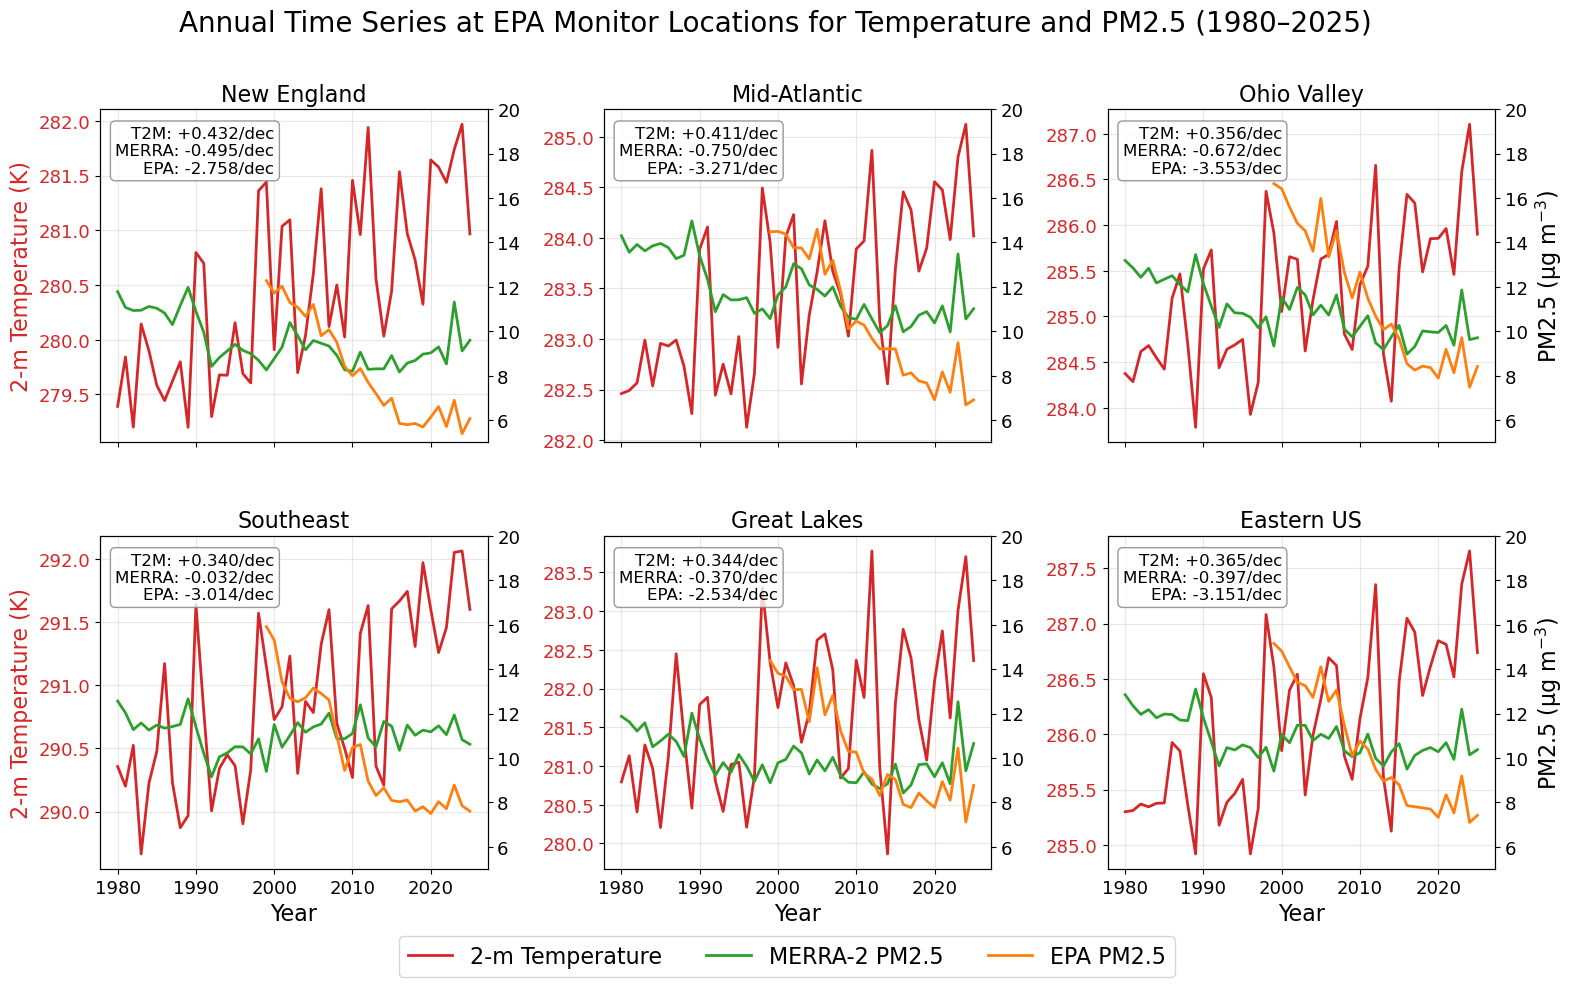

In [7]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import geopandas as gpd

# -----------------------------
# File paths
# -----------------------------
flux_file = "/scratch/sjacker2/project_data/merra2_rad_downloads/merra2_toa_upwelling_lw_sw_combined.nc"
pm25_t2m_file = "/scratch/sjacker2/project_data/merra2_pm25_t2m_eastern_us_monthly_fields_DRY.nc"
monitor_file = "/scratch/sjacker2/project_data/monthly_pm25_eastern_us_1999_2025.csv"
states_shp = "/scratch/sjacker2/project_data/cb_2018_us_state_500k.shp"

# -----------------------------
# Region definitions
# -----------------------------
REGIONS = {
    "New England": [
        "Connecticut", "Maine", "Massachusetts", "New Hampshire", "Rhode Island", "Vermont"
    ],
    "Mid-Atlantic": [
        "New Jersey", "New York", "Pennsylvania", "Delaware", "Maryland", "Virginia"
    ],
    "Ohio Valley": [
        "Indiana", "Kentucky", "Ohio", "West Virginia", "Tennessee"
    ],
    "Southeast": [
        "Alabama", "Florida", "Georgia", "Mississippi",
        "North Carolina", "South Carolina", "Arkansas", "Louisiana", "Missouri"
    ],
    "Great Lakes": [
        "Michigan", "Wisconsin", "Illinois"
    ],
}

REGION_ORDER = [
    "New England",
    "Mid-Atlantic",
    "Ohio Valley",
    "Southeast",
    "Great Lakes",
]

PANEL_ORDER = REGION_ORDER + ["Eastern US"]

STATE_TO_REGION = {
    state: region for region, states in REGIONS.items() for state in states
}

STATE_ABBR_TO_NAME = {
    "AL": "Alabama", "AR": "Arkansas", "CT": "Connecticut", "DE": "Delaware",
    "FL": "Florida", "GA": "Georgia", "IL": "Illinois", "IN": "Indiana",
    "KY": "Kentucky", "LA": "Louisiana", "ME": "Maine", "MA": "Massachusetts",
    "MI": "Michigan", "MS": "Mississippi", "MO": "Missouri", "NH": "New Hampshire",
    "NJ": "New Jersey", "NY": "New York", "NC": "North Carolina", "OH": "Ohio",
    "OK": "Oklahoma", "PA": "Pennsylvania", "RI": "Rhode Island",
    "SC": "South Carolina", "TN": "Tennessee", "TX": "Texas", "VT": "Vermont",
    "VA": "Virginia", "WV": "West Virginia", "WI": "Wisconsin"
}

STATE_FIPS_TO_NAME = {
    1: "Alabama", 5: "Arkansas", 9: "Connecticut", 10: "Delaware",
    12: "Florida", 13: "Georgia", 17: "Illinois", 18: "Indiana",
    21: "Kentucky", 22: "Louisiana", 23: "Maine", 25: "Massachusetts",
    26: "Michigan", 28: "Mississippi", 29: "Missouri", 33: "New Hampshire",
    34: "New Jersey", 36: "New York", 37: "North Carolina", 39: "Ohio",
    40: "Oklahoma", 42: "Pennsylvania", 44: "Rhode Island", 45: "South Carolina",
    47: "Tennessee", 48: "Texas", 50: "Vermont", 51: "Virginia",
    54: "West Virginia", 55: "Wisconsin"
}

# -----------------------------
# Helpers
# -----------------------------
def load_us_states_gdf(shp_path):
    states = gpd.read_file(shp_path).to_crs("EPSG:4326")

    if "NAME" not in states.columns:
        raise ValueError("Could not find NAME column in state shapefile.")

    states = states[states["NAME"].isin(STATE_TO_REGION.keys())].copy()
    states["state_name"] = states["NAME"]
    states["region"] = states["state_name"].map(STATE_TO_REGION)

    return states[["state_name", "region", "geometry"]]


def build_region_masks(lon, lat, states_gdf):
    lon2d, lat2d = np.meshgrid(lon.values, lat.values)

    grid = gpd.GeoDataFrame(
        {"lon": lon2d.ravel(), "lat": lat2d.ravel()},
        geometry=gpd.points_from_xy(lon2d.ravel(), lat2d.ravel()),
        crs="EPSG:4326"
    )

    joined = gpd.sjoin(
        grid,
        states_gdf[["region", "geometry"]],
        how="left",
        predicate="within"
    )

    masks = {}

    for region in REGION_ORDER:
        mask = joined["region"].eq(region).values.reshape(len(lat), len(lon))
        masks[region] = xr.DataArray(
            mask,
            coords={"lat": lat, "lon": lon},
            dims=("lat", "lon")
        )

    eastern_mask = joined["region"].notna().values.reshape(len(lat), len(lon))
    masks["Eastern US"] = xr.DataArray(
        eastern_mask,
        coords={"lat": lat, "lon": lon},
        dims=("lat", "lon")
    )

    return masks


def get_edges_from_centers(centers):
    centers = np.asarray(centers)

    edges = np.zeros(len(centers) + 1)
    edges[1:-1] = 0.5 * (centers[:-1] + centers[1:])
    edges[0] = centers[0] - 0.5 * (centers[1] - centers[0])
    edges[-1] = centers[-1] + 0.5 * (centers[-1] - centers[-2])

    return edges


def assign_monitors_to_grid(monitors, lats, lons):
    lat_edges = get_edges_from_centers(lats)
    lon_edges = get_edges_from_centers(lons)

    lat_idx = np.digitize(monitors["Latitude"].values, lat_edges) - 1
    lon_idx = np.digitize(monitors["Longitude"].values, lon_edges) - 1

    monitors = monitors.copy()
    monitors["lat_idx"] = lat_idx
    monitors["lon_idx"] = lon_idx

    monitors = monitors[
        (monitors["lat_idx"] >= 0) &
        (monitors["lat_idx"] < len(lats)) &
        (monitors["lon_idx"] >= 0) &
        (monitors["lon_idx"] < len(lons))
    ].copy()

    monitors["grid_lat"] = lats[monitors["lat_idx"].values]
    monitors["grid_lon"] = lons[monitors["lon_idx"].values]

    return monitors


def build_monitor_cell_mask(lon, lat, monitor_df):
    lats = lat.values
    lons = lon.values

    mon_locs = (
        monitor_df[["monitor_id", "Latitude", "Longitude"]]
        .drop_duplicates()
        .reset_index(drop=True)
    )

    mon_for_grid = mon_locs.copy()

    if np.nanmax(lons) > 180:
        mon_for_grid["Longitude"] = mon_for_grid["Longitude"] % 360

    mon_grid = assign_monitors_to_grid(mon_for_grid, lats, lons)

    unique_cells = (
        mon_grid[["lat_idx", "lon_idx"]]
        .drop_duplicates()
        .reset_index(drop=True)
    )

    mask = xr.zeros_like(
        xr.DataArray(
            np.zeros((len(lat), len(lon)), dtype=bool),
            coords={"lat": lat, "lon": lon},
            dims=("lat", "lon")
        ),
        dtype=bool
    )

    for _, row in unique_cells.iterrows():
        mask.values[int(row["lat_idx"]), int(row["lon_idx"])] = True

    return mask, mon_grid, unique_cells


def regional_weighted_mean_timeseries(da_3d, combined_mask_2d):
    weights = np.cos(np.deg2rad(da_3d["lat"]))
    masked = da_3d.where(combined_mask_2d)
    return masked.weighted(weights).mean(dim=("lat", "lon"))


def annualize_xr_timeseries(ts):
    return ts.groupby("time.year").mean()


def fit_trend_line(years, values):
    years = np.asarray(years, dtype=float)
    values = np.asarray(values, dtype=float)

    mask = np.isfinite(years) & np.isfinite(values)

    if mask.sum() < 2:
        return np.full_like(years, np.nan, dtype=float), np.nan

    coeffs = np.polyfit(years[mask], values[mask], 1)
    trendline = np.polyval(coeffs, years)

    return trendline, coeffs[0] * 10.0


def detect_monitor_state_column(df):
    for col in ["state_name", "state", "State Name", "state_full"]:
        if col in df.columns:
            return col, "name"

    for col in ["state_abbr", "state_code", "state_postal", "State Code"]:
        if col in df.columns:
            return col, "abbr"

    for col in ["state_fips", "State FIPS", "STATEFP", "statefp"]:
        if col in df.columns:
            return col, "fips"

    return None, None


def assign_monitor_regions(mon):
    state_col, state_kind = detect_monitor_state_column(mon)

    if state_col is None:
        raise ValueError(
            "Could not find a state column in the monitor CSV. "
            "Add one of: state_name/state, state_abbr/state_code, or state_fips."
        )

    mon = mon.copy()

    if state_kind == "name":
        mon["state_name_std"] = mon[state_col].astype(str).str.strip()

    elif state_kind == "abbr":
        mon["state_name_std"] = (
            mon[state_col]
            .astype(str)
            .str.strip()
            .str.upper()
            .map(STATE_ABBR_TO_NAME)
        )

    elif state_kind == "fips":
        mon["state_name_std"] = (
            pd.to_numeric(mon[state_col], errors="coerce")
            .map(STATE_FIPS_TO_NAME)
        )

    mon["region"] = mon["state_name_std"].map(STATE_TO_REGION)

    mon = mon.dropna(subset=["region"]).copy()

    return mon


def monitor_annual_series(mon, region=None):
    if region is None or region == "Eastern US":
        tmp = mon.copy()
    else:
        tmp = mon[mon["region"] == region].copy()

    monthly_mean = (
        tmp.groupby(["year", "month"], as_index=False)
        .agg(epa_pm25=("monthly_pm25_mean", "mean"))
    )

    annual_mean = (
        monthly_mean.groupby("year", as_index=False)
        .agg(epa_pm25=("epa_pm25", "mean"))
    )

    full_years = pd.DataFrame({"year": np.arange(1980, 2026)})
    annual_mean = full_years.merge(annual_mean, on="year", how="left")

    return annual_mean


# -----------------------------
# Read and process EPA monitor data
# -----------------------------
mon = pd.read_csv(monitor_file)
mon.columns = mon.columns.str.strip()

for col in ["Latitude", "Longitude", "year", "month", "monthly_pm25_mean"]:
    if col in mon.columns:
        mon[col] = pd.to_numeric(mon[col], errors="coerce")

mon = mon.dropna(
    subset=["Latitude", "Longitude", "year", "month", "monthly_pm25_mean"]
).copy()

if "monitor_id" not in mon.columns:
    mon["monitor_id"] = (
        mon["State Code"].astype(str).str.zfill(2) + "-" +
        mon["County Code"].astype(str).str.zfill(3) + "-" +
        mon["Site Num"].astype(str).str.zfill(4) + "-" +
        mon["POC"].astype(str)
    )

mon["year"] = mon["year"].astype(int)
mon["month"] = mon["month"].astype(int)

MIN_DAILY_VALUES = 1

if "n_daily_values" in mon.columns:
    mon = mon[mon["n_daily_values"] >= MIN_DAILY_VALUES].copy()

mon = assign_monitor_regions(mon)

# -----------------------------
# Load datasets
# -----------------------------
ds_flux = xr.open_dataset(flux_file)
ds_pm = xr.open_dataset(pm25_t2m_file)

ds_flux = ds_flux.sel(time=slice("1980-01-01", "2025-12-31"))
ds_pm = ds_pm.sel(time=slice("1980-01-01", "2025-12-31"))

# -----------------------------
# Build masks
# -----------------------------
states_gdf = load_us_states_gdf(states_shp)

region_masks = build_region_masks(
    ds_pm["lon"],
    ds_pm["lat"],
    states_gdf
)

monitor_cell_mask, monitor_grid, unique_cells = build_monitor_cell_mask(
    ds_pm["lon"],
    ds_pm["lat"],
    mon
)

print(f"Unique EPA monitors used: {mon['monitor_id'].nunique():,}")
print(f"Unique MERRA-2 grid cells containing monitors: {len(unique_cells):,}")

# -----------------------------
# Build annual series using ONLY monitor cells
# -----------------------------
years = np.arange(1980, 2026)
regional_series = {}

for panel_name in PANEL_ORDER:
    combined_mask = region_masks[panel_name] & monitor_cell_mask

    t2m_ts = regional_weighted_mean_timeseries(
        ds_pm["T2M"],
        combined_mask
    )

    merra_pm25_ts = regional_weighted_mean_timeseries(
        ds_pm["PM25_dry"],
        combined_mask
    )

    t2m_annual = annualize_xr_timeseries(t2m_ts)
    merra_pm25_annual = annualize_xr_timeseries(merra_pm25_ts)

    t2m_series = pd.Series(
        t2m_annual.values,
        index=t2m_annual["year"].values.astype(int)
    ).reindex(years)

    merra_series = pd.Series(
        merra_pm25_annual.values,
        index=merra_pm25_annual["year"].values.astype(int)
    ).reindex(years)

    epa_annual = monitor_annual_series(mon, panel_name)

    epa_series = pd.Series(
        epa_annual["epa_pm25"].values,
        index=epa_annual["year"].values.astype(int)
    ).reindex(years)

    regional_series[panel_name] = {
        "T2M": t2m_series,
        "MERRA_PM25": merra_series,
        "EPA_PM25": epa_series,
    }

# -----------------------------
# Plot: one panel per region + full eastern US
# -----------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True)
axes = axes.flatten()

t2m_color = "tab:red"
merra_color = "tab:green"
epa_color = "tab:orange"

legend_handles = None

for i, panel_name in enumerate(PANEL_ORDER):
    ax = axes[i]
    axr = ax.twinx()

    t2m_vals = regional_series[panel_name]["T2M"].values
    merra_vals = regional_series[panel_name]["MERRA_PM25"].values
    epa_vals = regional_series[panel_name]["EPA_PM25"].values

    # Main lines
    t2m_line = ax.plot(
        years,
        t2m_vals,
        color=t2m_color,
        linewidth=2,
        label="2-m temperature"
    )

    merra_line = axr.plot(
        years,
        merra_vals,
        color=merra_color,
        linewidth=2,
        label="MERRA-2 PM2.5"
    )

    epa_line = axr.plot(
        years,
        epa_vals,
        color=epa_color,
        linewidth=2,
        label="EPA PM2.5"
    )

    # Trend calculations
    t2m_trend, t2m_trend_dec = fit_trend_line(years, t2m_vals)
    merra_trend, merra_trend_dec = fit_trend_line(years, merra_vals)
    epa_trend, epa_trend_dec = fit_trend_line(years, epa_vals)

    # Uncomment if you want trend lines drawn
    # ax.plot(years, t2m_trend, color=t2m_color, linestyle="--", linewidth=2)
    # axr.plot(years, merra_trend, color=merra_color, linestyle="--", linewidth=2)
    # axr.plot(years, epa_trend, color=epa_color, linestyle="--", linewidth=2)

    ax.set_title(panel_name, fontsize=16)
    ax.grid(True, alpha=0.3)

    ax.tick_params(axis="x", labelsize=13)
    ax.tick_params(axis="y", labelsize=13, labelcolor=t2m_color)
    axr.tick_params(axis="y", labelsize=13)

    axr.set_ylim(5, 20)

    if i in [0, 3]:
        ax.set_ylabel(
            "2-m Temperature (K)",
            fontsize=16,
            color=t2m_color
        )

    if i in [2, 5]:
        axr.set_ylabel(
            "PM2.5 (µg m$^{-3}$)",
            fontsize=16
        )

    if i in [3, 4, 5]:
        ax.set_xlabel("Year", fontsize=16)

    trend_text = (
        f"T2M: {t2m_trend_dec:+.3f}/dec\n"
        f"MERRA: {merra_trend_dec:+.3f}/dec\n"
        f"EPA: {epa_trend_dec:+.3f}/dec"
    )

    ax.text(
        0.45,
        0.80,
        trend_text,
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=12,
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            alpha=0.8,
            edgecolor="gray"
        )
    )

    if legend_handles is None:
        legend_handles = [
            t2m_line[0],
            merra_line[0],
            epa_line[0]
        ]

fig.legend(
    legend_handles,
    ["2-m Temperature", "MERRA-2 PM2.5", "EPA PM2.5"],
    loc="lower center",
    ncol=3,
    frameon=True,
    fontsize=16
)

plt.subplots_adjust(bottom=0.12, wspace=0.30, hspace=0.28)

plt.suptitle(
    "Annual Time Series at EPA Monitor Locations for Temperature and PM2.5 (1980–2025)",
    fontsize=20
)

plt.show()

ERROR 1: PROJ: proj_create_from_database: Open of /projects/illinois/eng/cee/hmhorow/sjacker2/software/miniconda3/envs/climate/share/proj failed


               region  SW_up_trend  LW_up_trend  MERRA_PM25_trend  \
0         New England      -0.5194      -0.3539            0.0407   
1     Middle Atlantic      -0.2828      -0.7096           -0.3145   
2      South Atlantic       0.5423      -1.7167           -0.0792   
3  East North Central       0.2567      -0.9494           -0.0846   
4  East South Central       0.8685      -1.5377           -0.0479   

   EPA_PM25_trend  
0         -2.7839  
1         -3.0922  
2         -3.1653  
3         -3.0472  
4         -3.6177  


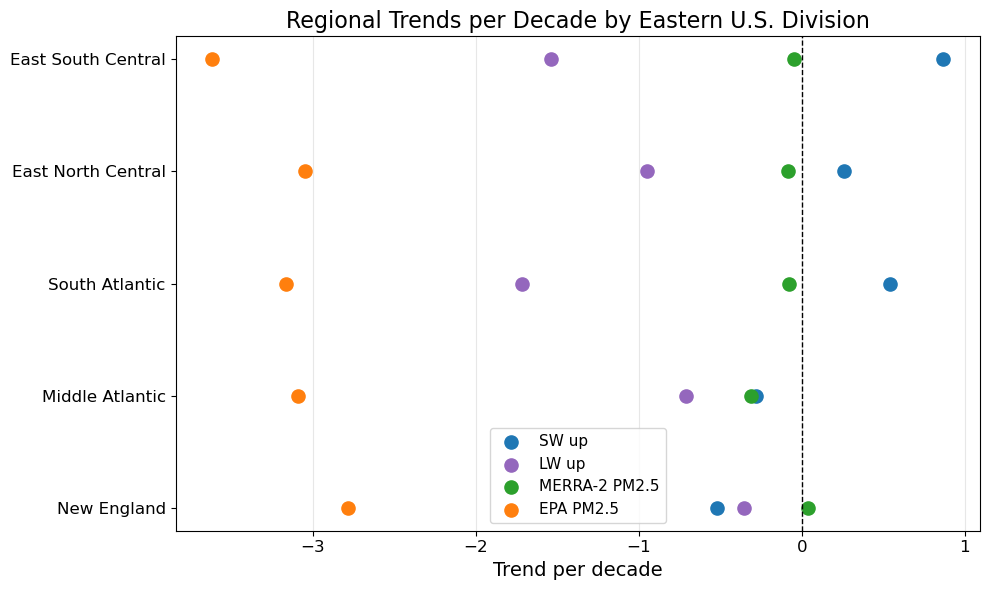

In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import geopandas as gpd

# -----------------------------
# File paths
# -----------------------------
flux_file = "/scratch/sjacker2/project_data/merra2_rad_downloads/merra2_toa_upwelling_lw_sw_combined.nc"
pm25_t2m_file = "/scratch/sjacker2/project_data/merra2_pm25_t2m_eastern_us_monthly_fields_DRY.nc"
monitor_file = "/scratch/sjacker2/project_data/monthly_pm25_eastern_us_1999_2025.csv"
states_shp = "/scratch/sjacker2/project_data/cb_2018_us_state_500k.shp"

# -----------------------------
# Region definitions
# -----------------------------
DIVISIONS = {
    "New England": [
        "Connecticut", "Maine", "Massachusetts", "New Hampshire", "Rhode Island", "Vermont"
    ],
    "Middle Atlantic": [
        "New Jersey", "New York", "Pennsylvania"
    ],
    "South Atlantic": [
        "Delaware", "District of Columbia", "Florida", "Georgia", "Maryland",
        "North Carolina", "South Carolina", "Virginia", "West Virginia"
    ],
    "East North Central": [
        "Illinois", "Indiana", "Michigan", "Ohio", "Wisconsin"
    ],
    "East South Central": [
        "Alabama", "Kentucky", "Mississippi", "Tennessee"
    ],
}
DIVISION_ORDER = [
    "New England",
    "Middle Atlantic",
    "South Atlantic",
    "East North Central",
    "East South Central",
]

STATE_TO_DIVISION = {
    state: div for div, states in DIVISIONS.items() for state in states
}

STATE_ABBR_TO_NAME = {
    "CT": "Connecticut", "ME": "Maine", "MA": "Massachusetts", "NH": "New Hampshire",
    "RI": "Rhode Island", "VT": "Vermont", "NJ": "New Jersey", "NY": "New York",
    "PA": "Pennsylvania", "DE": "Delaware", "DC": "District of Columbia",
    "FL": "Florida", "GA": "Georgia", "MD": "Maryland", "NC": "North Carolina",
    "SC": "South Carolina", "VA": "Virginia", "WV": "West Virginia",
    "IL": "Illinois", "IN": "Indiana", "MI": "Michigan", "OH": "Ohio",
    "WI": "Wisconsin", "AL": "Alabama", "KY": "Kentucky", "MS": "Mississippi",
    "TN": "Tennessee"
}
STATE_FIPS_TO_NAME = {
    9: "Connecticut", 23: "Maine", 25: "Massachusetts", 33: "New Hampshire",
    44: "Rhode Island", 50: "Vermont", 34: "New Jersey", 36: "New York",
    42: "Pennsylvania", 10: "Delaware", 11: "District of Columbia", 12: "Florida",
    13: "Georgia", 24: "Maryland", 37: "North Carolina", 45: "South Carolina",
    51: "Virginia", 54: "West Virginia", 17: "Illinois", 18: "Indiana",
    26: "Michigan", 39: "Ohio", 55: "Wisconsin", 1: "Alabama", 21: "Kentucky",
    28: "Mississippi", 47: "Tennessee"
}

# -----------------------------
# Helpers
# -----------------------------
def load_us_states_gdf(shp_path):
    states = gpd.read_file(shp_path).to_crs("EPSG:4326")
    if "NAME" not in states.columns:
        raise ValueError("Could not find NAME column in state shapefile.")
    states = states[states["NAME"].isin(STATE_TO_DIVISION.keys())].copy()
    states["state_name"] = states["NAME"]
    states["division"] = states["state_name"].map(STATE_TO_DIVISION)
    return states[["state_name", "division", "geometry"]]


def build_division_masks(lon, lat, states_gdf):
    lon2d, lat2d = np.meshgrid(lon.values, lat.values)

    grid = gpd.GeoDataFrame(
        {"lon": lon2d.ravel(), "lat": lat2d.ravel()},
        geometry=gpd.points_from_xy(lon2d.ravel(), lat2d.ravel()),
        crs="EPSG:4326"
    )

    joined = gpd.sjoin(
        grid,
        states_gdf[["division", "geometry"]],
        how="left",
        predicate="within"
    )

    masks = {}
    for div in DIVISION_ORDER:
        mask = joined["division"].eq(div).values.reshape(len(lat), len(lon))
        masks[div] = xr.DataArray(
            mask,
            coords={"lat": lat, "lon": lon},
            dims=("lat", "lon")
        )
    return masks


def regional_weighted_mean_timeseries(da_3d, mask_2d):
    weights = np.cos(np.deg2rad(da_3d["lat"]))
    masked = da_3d.where(mask_2d)
    return masked.weighted(weights).mean(dim=("lat", "lon"))


def trend_per_decade_from_timeseries(ts):
    years = pd.to_datetime(ts["time"].values)
    x = np.array([
        t.year + (t.dayofyear - 1) / (366 if t.is_leap_year else 365)
        for t in years
    ])
    y = ts.values

    mask = np.isfinite(x) & np.isfinite(y)
    coeffs = np.polyfit(x[mask], y[mask], 1)
    return coeffs[0] * 10.0


def detect_monitor_state_column(df):
    for col in ["state_name", "state", "State Name", "state_full"]:
        if col in df.columns:
            return col, "name"
    for col in ["state_abbr", "state_code", "state_postal", "State Code"]:
        if col in df.columns:
            return col, "abbr"
    for col in ["state_fips", "State FIPS", "STATEFP", "statefp"]:
        if col in df.columns:
            return col, "fips"
    return None, None


def assign_monitor_divisions(mon):
    state_col, state_kind = detect_monitor_state_column(mon)

    if state_col is None:
        raise ValueError(
            "Could not find a state column in the monitor CSV. "
            "Add one of: state_name/state, state_abbr/state_code, or state_fips."
        )

    if state_kind == "name":
        mon["state_name_std"] = mon[state_col].astype(str).str.strip()
    elif state_kind == "abbr":
        mon["state_name_std"] = (
            mon[state_col].astype(str).str.strip().str.upper().map(STATE_ABBR_TO_NAME)
        )
    elif state_kind == "fips":
        mon["state_name_std"] = pd.to_numeric(mon[state_col], errors="coerce").map(STATE_FIPS_TO_NAME)

    mon["division"] = mon["state_name_std"].map(STATE_TO_DIVISION)
    mon = mon.dropna(subset=["division"]).copy()
    return mon


def monitor_region_monthly_series(mon, division):
    tmp = mon[mon["division"] == division].copy()

    monthly_region = (
        tmp.groupby(["year", "month"], as_index=False)
        .agg(epa_pm25=("monthly_pm25_mean", "mean"))
    )

    monthly_region["time"] = pd.to_datetime(
        dict(year=monthly_region["year"], month=monthly_region["month"], day=1)
    )
    monthly_region = monthly_region.sort_values("time")

    return monthly_region


# -----------------------------
# Load datasets
# -----------------------------
ds_flux = xr.open_dataset(flux_file)
ds_pm = xr.open_dataset(pm25_t2m_file)

# Common period for monitor comparison
start_date = "1999-01-01"
end_date = "2025-12-31"

ds_flux = ds_flux.sel(time=slice(start_date, end_date))
ds_pm = ds_pm.sel(time=slice(start_date, end_date))

# -----------------------------
# Build masks
# -----------------------------
states_gdf = load_us_states_gdf(states_shp)
masks = build_division_masks(ds_flux["lon"], ds_flux["lat"], states_gdf)

# -----------------------------
# Build regional monthly time series
# -----------------------------
regional_rows = []

for div in DIVISION_ORDER:
    sw_ts = regional_weighted_mean_timeseries(ds_flux["TOA_SW_UP"], masks[div])
    lw_ts = regional_weighted_mean_timeseries(ds_flux["TOA_LW_UP"], masks[div])
    merra_pm25_ts = regional_weighted_mean_timeseries(ds_pm["PM25_dry"], masks[div])

    sw_trend = trend_per_decade_from_timeseries(sw_ts)
    lw_trend = trend_per_decade_from_timeseries(lw_ts)
    merra_pm25_trend = trend_per_decade_from_timeseries(merra_pm25_ts)

    regional_rows.append({
        "region": div,
        "SW_up_trend": sw_trend,
        "LW_up_trend": lw_trend,
        "MERRA_PM25_trend": merra_pm25_trend,
    })

trend_df = pd.DataFrame(regional_rows)

# -----------------------------
# Read and process EPA monitor data
# -----------------------------
mon = pd.read_csv(monitor_file)
mon["year"] = pd.to_numeric(mon["year"], errors="coerce")
mon["month"] = pd.to_numeric(mon["month"], errors="coerce")
mon["monthly_pm25_mean"] = pd.to_numeric(mon["monthly_pm25_mean"], errors="coerce")
mon = mon.dropna(subset=["year", "month", "monthly_pm25_mean"]).copy()
mon["year"] = mon["year"].astype(int)
mon["month"] = mon["month"].astype(int)

MIN_DAILY_VALUES = 1
if "n_daily_values" in mon.columns:
    mon = mon[mon["n_daily_values"] >= MIN_DAILY_VALUES].copy()

mon = assign_monitor_divisions(mon)
mon = mon[(mon["year"] >= 1999) & (mon["year"] <= 2025)].copy()

# -----------------------------
# Add EPA monitor trends
# -----------------------------
epa_trends = []
for div in DIVISION_ORDER:
    ts_df = monitor_region_monthly_series(mon, div)
    if len(ts_df) < 2:
        epa_trends.append(np.nan)
        continue

    x = np.array([
        t.year + (t.dayofyear - 1) / (366 if t.is_leap_year else 365)
        for t in ts_df["time"]
    ])
    y = ts_df["epa_pm25"].values

    mask = np.isfinite(x) & np.isfinite(y)
    coeffs = np.polyfit(x[mask], y[mask], 1)
    epa_trends.append(coeffs[0] * 10.0)

trend_df["EPA_PM25_trend"] = epa_trends

print(trend_df.round(4))

# -----------------------------
# Dot plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6))

ypos = np.arange(len(DIVISION_ORDER))

ax.scatter(
    trend_df["SW_up_trend"], ypos,
    s=90, label="SW up", color="tab:blue"
)
ax.scatter(
    trend_df["LW_up_trend"], ypos,
    s=90, label="LW up", color="tab:purple"
)
ax.scatter(
    trend_df["MERRA_PM25_trend"], ypos,
    s=90, label="MERRA-2 PM2.5", color="tab:green"
)
ax.scatter(
    trend_df["EPA_PM25_trend"], ypos,
    s=90, label="EPA PM2.5", color="tab:orange"
)

ax.axvline(0, color="black", linestyle="--", linewidth=1)

ax.set_yticks(ypos)
ax.set_yticklabels(DIVISION_ORDER, fontsize=12)
ax.set_xlabel("Trend per decade", fontsize=14)
ax.set_title("Regional Trends per Decade by Eastern U.S. Division", fontsize=16)
ax.tick_params(axis="x", labelsize=12)
ax.grid(True, axis="x", alpha=0.3)
ax.legend(fontsize=11, frameon=True)

plt.tight_layout()
plt.show()

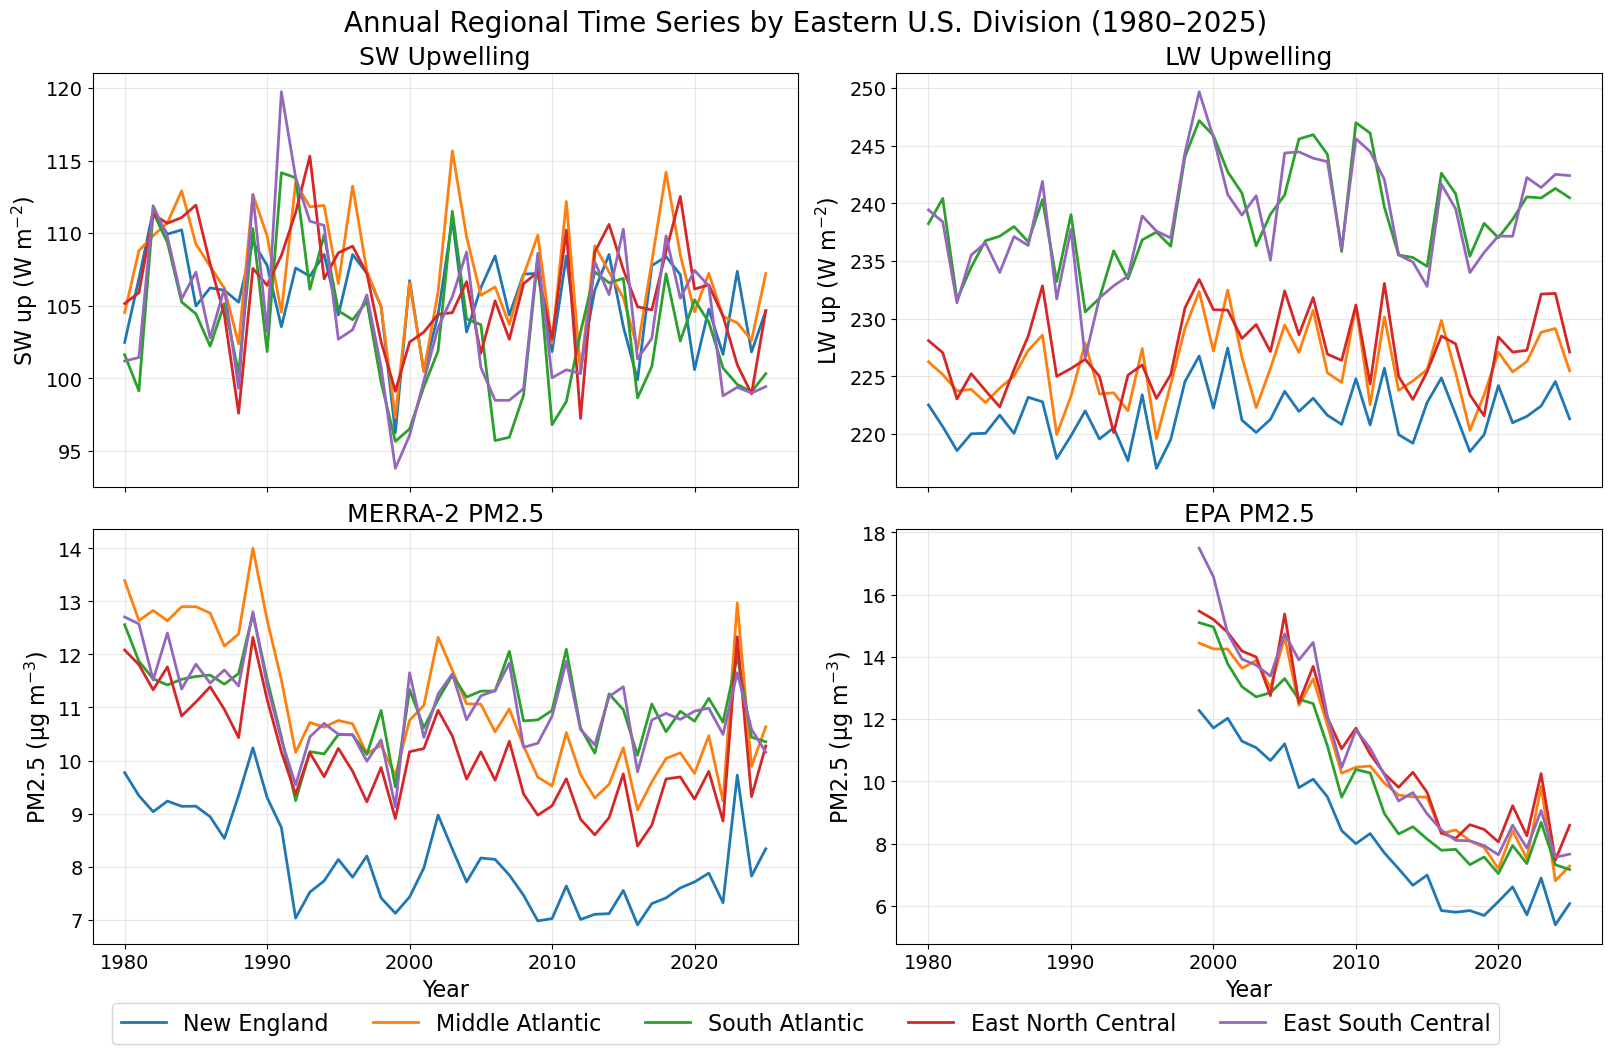

In [4]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import geopandas as gpd

# -----------------------------
# File paths
# -----------------------------
flux_file = "/scratch/sjacker2/project_data/merra2_rad_downloads/merra2_toa_upwelling_lw_sw_combined.nc"
pm25_t2m_file = "/scratch/sjacker2/project_data/merra2_pm25_t2m_eastern_us_monthly_fields_DRY.nc"
monitor_file = "/scratch/sjacker2/project_data/monthly_pm25_eastern_us_1999_2025.csv"
states_shp = "/scratch/sjacker2/project_data/cb_2018_us_state_500k.shp"

# -----------------------------
# Region definitions
# -----------------------------
DIVISIONS = {
    "New England": [
        "Connecticut", "Maine", "Massachusetts", "New Hampshire", "Rhode Island", "Vermont"
    ],
    "Middle Atlantic": [
        "New Jersey", "New York", "Pennsylvania"
    ],
    "South Atlantic": [
        "Delaware", "District of Columbia", "Florida", "Georgia", "Maryland",
        "North Carolina", "South Carolina", "Virginia", "West Virginia"
    ],
    "East North Central": [
        "Illinois", "Indiana", "Michigan", "Ohio", "Wisconsin"
    ],
    "East South Central": [
        "Alabama", "Kentucky", "Mississippi", "Tennessee"
    ],
}
DIVISION_ORDER = [
    "New England",
    "Middle Atlantic",
    "South Atlantic",
    "East North Central",
    "East South Central",
]

STATE_TO_DIVISION = {
    state: div for div, states in DIVISIONS.items() for state in states
}

STATE_ABBR_TO_NAME = {
    "CT": "Connecticut", "ME": "Maine", "MA": "Massachusetts", "NH": "New Hampshire",
    "RI": "Rhode Island", "VT": "Vermont", "NJ": "New Jersey", "NY": "New York",
    "PA": "Pennsylvania", "DE": "Delaware", "DC": "District of Columbia",
    "FL": "Florida", "GA": "Georgia", "MD": "Maryland", "NC": "North Carolina",
    "SC": "South Carolina", "VA": "Virginia", "WV": "West Virginia",
    "IL": "Illinois", "IN": "Indiana", "MI": "Michigan", "OH": "Ohio",
    "WI": "Wisconsin", "AL": "Alabama", "KY": "Kentucky", "MS": "Mississippi",
    "TN": "Tennessee"
}
STATE_FIPS_TO_NAME = {
    9: "Connecticut", 23: "Maine", 25: "Massachusetts", 33: "New Hampshire",
    44: "Rhode Island", 50: "Vermont", 34: "New Jersey", 36: "New York",
    42: "Pennsylvania", 10: "Delaware", 11: "District of Columbia", 12: "Florida",
    13: "Georgia", 24: "Maryland", 37: "North Carolina", 45: "South Carolina",
    51: "Virginia", 54: "West Virginia", 17: "Illinois", 18: "Indiana",
    26: "Michigan", 39: "Ohio", 55: "Wisconsin", 1: "Alabama", 21: "Kentucky",
    28: "Mississippi", 47: "Tennessee"
}

# -----------------------------
# Helpers
# -----------------------------
def load_us_states_gdf(shp_path):
    states = gpd.read_file(shp_path).to_crs("EPSG:4326")
    if "NAME" not in states.columns:
        raise ValueError("Could not find NAME column in state shapefile.")
    states = states[states["NAME"].isin(STATE_TO_DIVISION.keys())].copy()
    states["state_name"] = states["NAME"]
    states["division"] = states["state_name"].map(STATE_TO_DIVISION)
    return states[["state_name", "division", "geometry"]]


def build_division_masks(lon, lat, states_gdf):
    lon2d, lat2d = np.meshgrid(lon.values, lat.values)

    grid = gpd.GeoDataFrame(
        {"lon": lon2d.ravel(), "lat": lat2d.ravel()},
        geometry=gpd.points_from_xy(lon2d.ravel(), lat2d.ravel()),
        crs="EPSG:4326"
    )

    joined = gpd.sjoin(
        grid,
        states_gdf[["division", "geometry"]],
        how="left",
        predicate="within"
    )

    masks = {}
    for div in DIVISION_ORDER:
        mask = joined["division"].eq(div).values.reshape(len(lat), len(lon))
        masks[div] = xr.DataArray(
            mask,
            coords={"lat": lat, "lon": lon},
            dims=("lat", "lon")
        )
    return masks


def regional_weighted_mean_timeseries(da_3d, mask_2d):
    weights = np.cos(np.deg2rad(da_3d["lat"]))
    masked = da_3d.where(mask_2d)
    return masked.weighted(weights).mean(dim=("lat", "lon"))


def annualize_xr_timeseries(ts):
    return ts.groupby("time.year").mean()


def detect_monitor_state_column(df):
    for col in ["state_name", "state", "State Name", "state_full"]:
        if col in df.columns:
            return col, "name"
    for col in ["state_abbr", "state_code", "state_postal", "State Code"]:
        if col in df.columns:
            return col, "abbr"
    for col in ["state_fips", "State FIPS", "STATEFP", "statefp"]:
        if col in df.columns:
            return col, "fips"
    return None, None


def assign_monitor_divisions(mon):
    state_col, state_kind = detect_monitor_state_column(mon)

    if state_col is None:
        raise ValueError(
            "Could not find a state column in the monitor CSV. "
            "Add one of: state_name/state, state_abbr/state_code, or state_fips."
        )

    if state_kind == "name":
        mon["state_name_std"] = mon[state_col].astype(str).str.strip()
    elif state_kind == "abbr":
        mon["state_name_std"] = (
            mon[state_col].astype(str).str.strip().str.upper().map(STATE_ABBR_TO_NAME)
        )
    elif state_kind == "fips":
        mon["state_name_std"] = pd.to_numeric(mon[state_col], errors="coerce").map(STATE_FIPS_TO_NAME)

    mon["division"] = mon["state_name_std"].map(STATE_TO_DIVISION)
    mon = mon.dropna(subset=["division"]).copy()
    return mon


def monitor_region_annual_series(mon, division):
    tmp = mon[mon["division"] == division].copy()

    monthly_region = (
        tmp.groupby(["year", "month"], as_index=False)
        .agg(epa_pm25=("monthly_pm25_mean", "mean"))
    )

    annual_region = (
        monthly_region.groupby("year", as_index=False)
        .agg(epa_pm25=("epa_pm25", "mean"))
    )

    full_years = pd.DataFrame({"year": np.arange(1980, 2026)})
    annual_region = full_years.merge(annual_region, on="year", how="left")

    return annual_region


# -----------------------------
# Load datasets
# -----------------------------
ds_flux = xr.open_dataset(flux_file)
ds_pm = xr.open_dataset(pm25_t2m_file)

ds_flux = ds_flux.sel(time=slice("1980-01-01", "2025-12-31"))
ds_pm = ds_pm.sel(time=slice("1980-01-01", "2025-12-31"))

# -----------------------------
# Build masks
# -----------------------------
states_gdf = load_us_states_gdf(states_shp)
masks = build_division_masks(ds_flux["lon"], ds_flux["lat"], states_gdf)

# -----------------------------
# Build regional annual time series
# -----------------------------
annual_data = {
    "SW_up": {},
    "LW_up": {},
    "MERRA_PM25": {},
    "EPA_PM25": {},
}

for div in DIVISION_ORDER:
    sw_ts = regional_weighted_mean_timeseries(ds_flux["TOA_SW_UP"], masks[div])
    lw_ts = regional_weighted_mean_timeseries(ds_flux["TOA_LW_UP"], masks[div])
    merra_pm25_ts = regional_weighted_mean_timeseries(ds_pm["PM25_dry"], masks[div])

    sw_annual = annualize_xr_timeseries(sw_ts)
    lw_annual = annualize_xr_timeseries(lw_ts)
    merra_pm25_annual = annualize_xr_timeseries(merra_pm25_ts)

    annual_data["SW_up"][div] = pd.Series(
        sw_annual.values, index=sw_annual["year"].values.astype(int)
    )
    annual_data["LW_up"][div] = pd.Series(
        lw_annual.values, index=lw_annual["year"].values.astype(int)
    )
    annual_data["MERRA_PM25"][div] = pd.Series(
        merra_pm25_annual.values, index=merra_pm25_annual["year"].values.astype(int)
    )

# -----------------------------
# Read and process EPA monitor data
# -----------------------------
mon = pd.read_csv(monitor_file)
mon["year"] = pd.to_numeric(mon["year"], errors="coerce")
mon["month"] = pd.to_numeric(mon["month"], errors="coerce")
mon["monthly_pm25_mean"] = pd.to_numeric(mon["monthly_pm25_mean"], errors="coerce")
mon = mon.dropna(subset=["year", "month", "monthly_pm25_mean"]).copy()
mon["year"] = mon["year"].astype(int)
mon["month"] = mon["month"].astype(int)

MIN_DAILY_VALUES = 1
if "n_daily_values" in mon.columns:
    mon = mon[mon["n_daily_values"] >= MIN_DAILY_VALUES].copy()

mon = assign_monitor_divisions(mon)

for div in DIVISION_ORDER:
    epa_annual = monitor_region_annual_series(mon, div)
    annual_data["EPA_PM25"][div] = pd.Series(
        epa_annual["epa_pm25"].values,
        index=epa_annual["year"].values.astype(int)
    )

# -----------------------------
# Plot
# -----------------------------
years = np.arange(1980, 2026)

region_colors = {
    "New England": "tab:blue",
    "Middle Atlantic": "tab:orange",
    "South Atlantic": "tab:green",
    "East North Central": "tab:red",
    "East South Central": "tab:purple",
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, constrained_layout=True)

panel_info = [
    ("SW_up", "SW Upwelling", "SW up (W m$^{-2}$)", axes[0, 0]),
    ("LW_up", "LW Upwelling", "LW up (W m$^{-2}$)", axes[0, 1]),
    ("MERRA_PM25", "MERRA-2 PM2.5", "PM2.5 (µg m$^{-3}$)", axes[1, 0]),
    ("EPA_PM25", "EPA PM2.5", "PM2.5 (µg m$^{-3}$)", axes[1, 1]),
]

for key, title, ylabel, ax in panel_info:
    for div in DIVISION_ORDER:
        series = annual_data[key][div].reindex(years)
        ax.plot(
            years,
            series.values,
            linewidth=2,
            label=div,
            color=region_colors[div]
        )

    ax.set_title(title, fontsize=18)
    ax.set_ylabel(ylabel, fontsize=16)
    ax.tick_params(axis="both", labelsize=14)
    ax.grid(True, alpha=0.3)

for ax in axes[1, :]:
    ax.set_xlabel("Year", fontsize=16)

# one shared legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=5,
    frameon=True,
    fontsize=16
)

plt.suptitle("Annual Regional Time Series by Eastern U.S. Division (1980–2025)", fontsize=20)
plt.show()

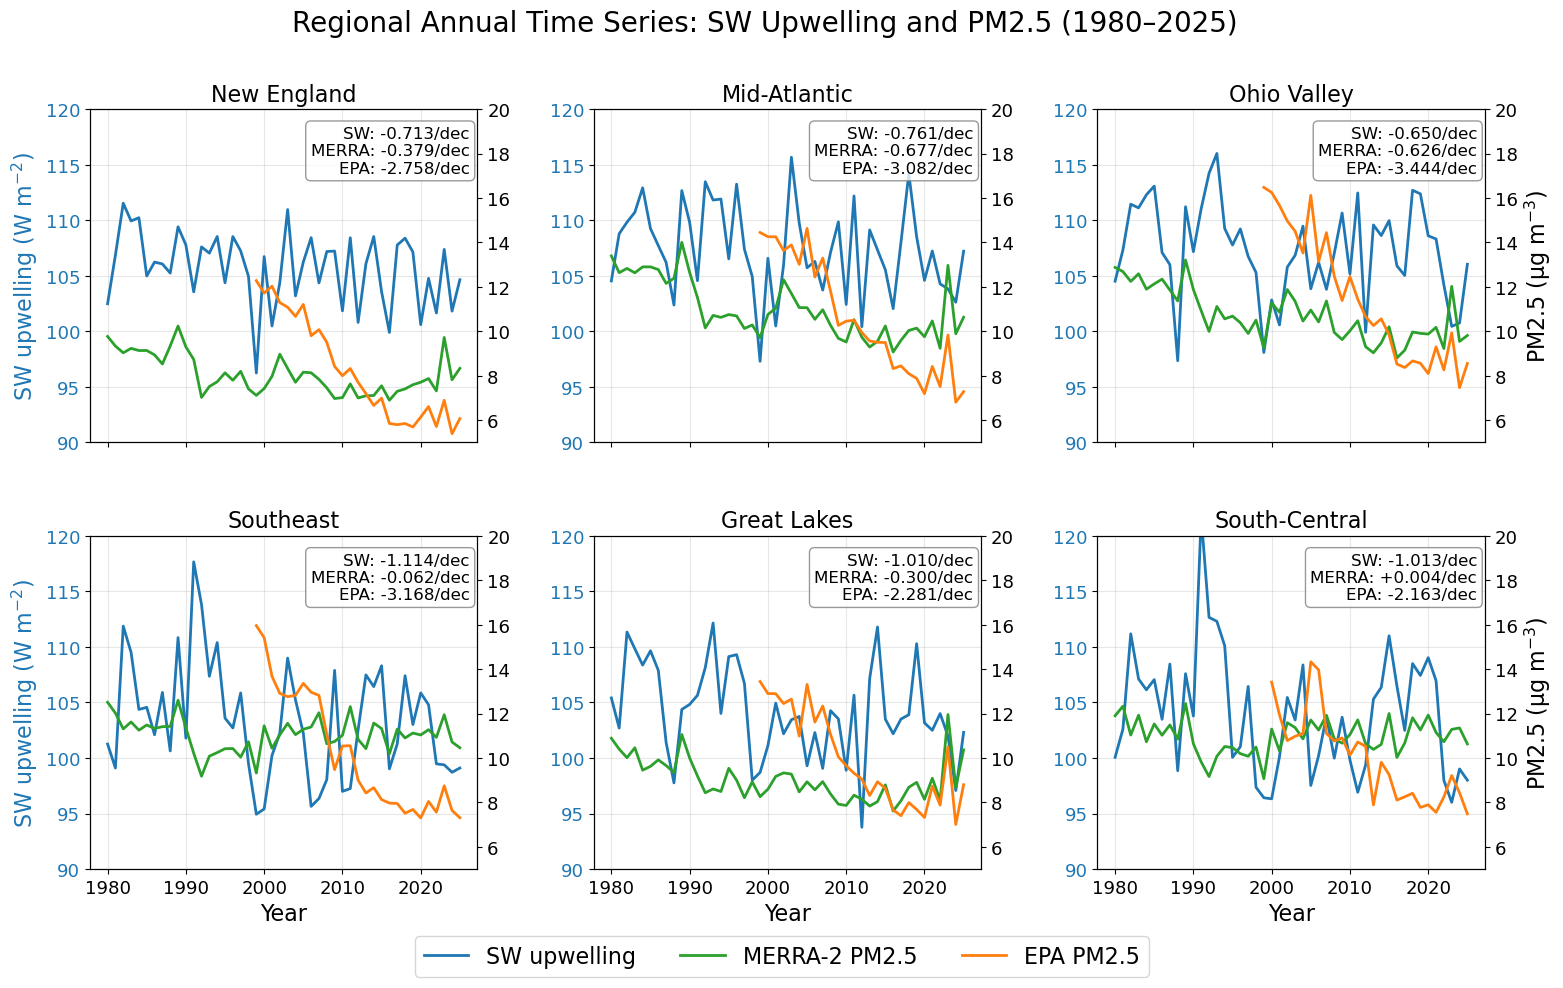

In [3]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import geopandas as gpd

# -----------------------------
# File paths
# -----------------------------
flux_file = "/scratch/sjacker2/project_data/merra2_rad_downloads/merra2_toa_upwelling_lw_sw_combined.nc"
pm25_t2m_file = "/scratch/sjacker2/project_data/merra2_pm25_t2m_eastern_us_monthly_fields_DRY.nc"
monitor_file = "/scratch/sjacker2/project_data/monthly_pm25_eastern_us_1999_2025.csv"
states_shp = "/scratch/sjacker2/project_data/cb_2018_us_state_500k.shp"

# -----------------------------
# Region definitions
# NOTE:
# These are editable assumptions for your new region groupings.
# Change any state assignments here if you want a different grouping.
# -----------------------------
REGIONS = {
    "New England": [
        "Connecticut", "Maine", "Massachusetts", "New Hampshire", "Rhode Island", "Vermont"
    ],
    "Mid-Atlantic": [
        "New Jersey", "New York", "Pennsylvania"
    ],
    "Ohio Valley": [
        "Illinois", "Indiana", "Kentucky", "Ohio", "West Virginia"
    ],
    "Southeast": [
        "Alabama", "Florida", "Georgia", "Mississippi",
        "North Carolina", "South Carolina", "Tennessee", "Virginia"
    ],
    "Great Lakes": [
        "Michigan", "Wisconsin"
    ],
    "South-Central": [
        "Arkansas", "Louisiana", "Missouri", "Oklahoma", "Texas"
    ],
}

REGION_ORDER = [
    "New England",
    "Mid-Atlantic",
    "Ohio Valley",
    "Southeast",
    "Great Lakes",
    "South-Central",
]

STATE_TO_REGION = {
    state: region for region, states in REGIONS.items() for state in states
}

STATE_ABBR_TO_NAME = {
    "AL": "Alabama", "AR": "Arkansas", "CT": "Connecticut", "DE": "Delaware",
    "FL": "Florida", "GA": "Georgia", "IL": "Illinois", "IN": "Indiana",
    "KY": "Kentucky", "LA": "Louisiana", "ME": "Maine", "MA": "Massachusetts",
    "MI": "Michigan", "MS": "Mississippi", "MO": "Missouri", "NH": "New Hampshire",
    "NJ": "New Jersey", "NY": "New York", "NC": "North Carolina", "OH": "Ohio",
    "OK": "Oklahoma", "PA": "Pennsylvania", "RI": "Rhode Island",
    "SC": "South Carolina", "TN": "Tennessee", "TX": "Texas", "VT": "Vermont",
    "VA": "Virginia", "WV": "West Virginia", "WI": "Wisconsin"
}

STATE_FIPS_TO_NAME = {
    1: "Alabama", 5: "Arkansas", 9: "Connecticut", 10: "Delaware",
    12: "Florida", 13: "Georgia", 17: "Illinois", 18: "Indiana",
    21: "Kentucky", 22: "Louisiana", 23: "Maine", 25: "Massachusetts",
    26: "Michigan", 28: "Mississippi", 29: "Missouri", 33: "New Hampshire",
    34: "New Jersey", 36: "New York", 37: "North Carolina", 39: "Ohio",
    40: "Oklahoma", 42: "Pennsylvania", 44: "Rhode Island", 45: "South Carolina",
    47: "Tennessee", 48: "Texas", 50: "Vermont", 51: "Virginia",
    54: "West Virginia", 55: "Wisconsin"
}

# -----------------------------
# Helpers
# -----------------------------
def load_us_states_gdf(shp_path):
    states = gpd.read_file(shp_path).to_crs("EPSG:4326")
    if "NAME" not in states.columns:
        raise ValueError("Could not find NAME column in state shapefile.")
    states = states[states["NAME"].isin(STATE_TO_REGION.keys())].copy()
    states["state_name"] = states["NAME"]
    states["region"] = states["state_name"].map(STATE_TO_REGION)
    return states[["state_name", "region", "geometry"]]


def build_region_masks(lon, lat, states_gdf):
    lon2d, lat2d = np.meshgrid(lon.values, lat.values)

    grid = gpd.GeoDataFrame(
        {"lon": lon2d.ravel(), "lat": lat2d.ravel()},
        geometry=gpd.points_from_xy(lon2d.ravel(), lat2d.ravel()),
        crs="EPSG:4326"
    )

    joined = gpd.sjoin(
        grid,
        states_gdf[["region", "geometry"]],
        how="left",
        predicate="within"
    )

    masks = {}
    for region in REGION_ORDER:
        mask = joined["region"].eq(region).values.reshape(len(lat), len(lon))
        masks[region] = xr.DataArray(
            mask,
            coords={"lat": lat, "lon": lon},
            dims=("lat", "lon")
        )
    return masks


def regional_weighted_mean_timeseries(da_3d, mask_2d):
    weights = np.cos(np.deg2rad(da_3d["lat"]))
    masked = da_3d.where(mask_2d)
    return masked.weighted(weights).mean(dim=("lat", "lon"))


def annualize_xr_timeseries(ts):
    return ts.groupby("time.year").mean()


def fit_trend_line(years, values):
    years = np.asarray(years, dtype=float)
    values = np.asarray(values, dtype=float)

    mask = np.isfinite(years) & np.isfinite(values)
    if mask.sum() < 2:
        return np.full_like(years, np.nan, dtype=float), np.nan

    coeffs = np.polyfit(years[mask], values[mask], 1)
    trendline = np.polyval(coeffs, years)
    return trendline, coeffs[0] * 10.0


def detect_monitor_state_column(df):
    for col in ["state_name", "state", "State Name", "state_full"]:
        if col in df.columns:
            return col, "name"
    for col in ["state_abbr", "state_code", "state_postal", "State Code"]:
        if col in df.columns:
            return col, "abbr"
    for col in ["state_fips", "State FIPS", "STATEFP", "statefp"]:
        if col in df.columns:
            return col, "fips"
    return None, None


def assign_monitor_regions(mon):
    state_col, state_kind = detect_monitor_state_column(mon)

    if state_col is None:
        raise ValueError(
            "Could not find a state column in the monitor CSV. "
            "Add one of: state_name/state, state_abbr/state_code, or state_fips."
        )

    if state_kind == "name":
        mon["state_name_std"] = mon[state_col].astype(str).str.strip()
    elif state_kind == "abbr":
        mon["state_name_std"] = (
            mon[state_col].astype(str).str.strip().str.upper().map(STATE_ABBR_TO_NAME)
        )
    elif state_kind == "fips":
        mon["state_name_std"] = pd.to_numeric(mon[state_col], errors="coerce").map(STATE_FIPS_TO_NAME)

    mon["region"] = mon["state_name_std"].map(STATE_TO_REGION)
    mon = mon.dropna(subset=["region"]).copy()
    return mon


def monitor_region_annual_series(mon, region):
    tmp = mon[mon["region"] == region].copy()

    monthly_region = (
        tmp.groupby(["year", "month"], as_index=False)
        .agg(epa_pm25=("monthly_pm25_mean", "mean"))
    )

    annual_region = (
        monthly_region.groupby("year", as_index=False)
        .agg(epa_pm25=("epa_pm25", "mean"))
    )

    full_years = pd.DataFrame({"year": np.arange(1980, 2026)})
    annual_region = full_years.merge(annual_region, on="year", how="left")

    return annual_region


# -----------------------------
# Load datasets
# -----------------------------
ds_flux = xr.open_dataset(flux_file)
ds_pm = xr.open_dataset(pm25_t2m_file)

ds_flux = ds_flux.sel(time=slice("1980-01-01", "2025-12-31"))
ds_pm = ds_pm.sel(time=slice("1980-01-01", "2025-12-31"))

# -----------------------------
# Build masks
# -----------------------------
states_gdf = load_us_states_gdf(states_shp)
masks = build_region_masks(ds_flux["lon"], ds_flux["lat"], states_gdf)

# -----------------------------
# Build annual regional series
# -----------------------------
years = np.arange(1980, 2026)

regional_series = {}

for region in REGION_ORDER:
    sw_ts = regional_weighted_mean_timeseries(ds_flux["TOA_SW_UP"], masks[region])
    merra_pm25_ts = regional_weighted_mean_timeseries(ds_pm["PM25_dry"], masks[region])

    sw_annual = annualize_xr_timeseries(sw_ts)
    merra_pm25_annual = annualize_xr_timeseries(merra_pm25_ts)

    sw_series = pd.Series(sw_annual.values, index=sw_annual["year"].values.astype(int)).reindex(years)
    merra_series = pd.Series(
        merra_pm25_annual.values,
        index=merra_pm25_annual["year"].values.astype(int)
    ).reindex(years)

    regional_series[region] = {
        "SW_up": sw_series,
        "MERRA_PM25": merra_series,
    }

# -----------------------------
# Read and process EPA monitor data
# -----------------------------
mon = pd.read_csv(monitor_file)
mon["year"] = pd.to_numeric(mon["year"], errors="coerce")
mon["month"] = pd.to_numeric(mon["month"], errors="coerce")
mon["monthly_pm25_mean"] = pd.to_numeric(mon["monthly_pm25_mean"], errors="coerce")
mon = mon.dropna(subset=["year", "month", "monthly_pm25_mean"]).copy()
mon["year"] = mon["year"].astype(int)
mon["month"] = mon["month"].astype(int)

MIN_DAILY_VALUES = 1
if "n_daily_values" in mon.columns:
    mon = mon[mon["n_daily_values"] >= MIN_DAILY_VALUES].copy()

mon = assign_monitor_regions(mon)

for region in REGION_ORDER:
    epa_annual = monitor_region_annual_series(mon, region)
    epa_series = pd.Series(
        epa_annual["epa_pm25"].values,
        index=epa_annual["year"].values.astype(int)
    ).reindex(years)
    regional_series[region]["EPA_PM25"] = epa_series

# -----------------------------
# Plot: one panel per region
# -----------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True)
axes = axes.flatten()

sw_color = "tab:blue"
merra_color = "tab:green"
epa_color = "tab:orange"

# save legend handles from first panel
legend_handles = None

for i, region in enumerate(REGION_ORDER):
    ax = axes[i]
    axr = ax.twinx()

    sw_vals = regional_series[region]["SW_up"].values
    merra_vals = regional_series[region]["MERRA_PM25"].values
    epa_vals = regional_series[region]["EPA_PM25"].values

    # main lines
    sw_line = ax.plot(years, sw_vals, color=sw_color, linewidth=2, label="SW upwelling")
    merra_line = axr.plot(years, merra_vals, color=merra_color, linewidth=2, label="MERRA-2 PM2.5")
    epa_line = axr.plot(years, epa_vals, color=epa_color, linewidth=2, label="EPA PM2.5")

    # trend lines (same color, dashed, not labeled)
    sw_trend, sw_trend_dec = fit_trend_line(years, sw_vals)
    merra_trend, merra_trend_dec = fit_trend_line(years, merra_vals)
    epa_trend, epa_trend_dec = fit_trend_line(years, epa_vals)

    #ax.plot(years, sw_trend, color=sw_color, linestyle="--", linewidth=2)
    #axr.plot(years, merra_trend, color=merra_color, linestyle="--", linewidth=2)
    #axr.plot(years, epa_trend, color=epa_color, linestyle="--", linewidth=2)

    # axis formatting
    ax.set_title(region, fontsize=16)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", labelsize=13)
    ax.tick_params(axis="y", labelsize=13, labelcolor=sw_color)
    axr.tick_params(axis="y", labelsize=13)

    # fixed PM2.5 axis range
    axr.set_ylim(5, 20)
    ax.set_ylim(90,120)

    # left y-label only on left column
    if i in [0, 3]:
        ax.set_ylabel("SW upwelling (W m$^{-2}$)", fontsize=16, color=sw_color)

    # right y-label on right column panels
    if i in [2, 5]:
        axr.set_ylabel("PM2.5 (µg m$^{-3}$)", fontsize=16)

    # x-label on bottom row only
    if i in [3, 4, 5]:
        ax.set_xlabel("Year", fontsize=16)

    # trend text box
    trend_text = (
        f"SW: {sw_trend_dec:+.3f}/dec\n"
        f"MERRA: {merra_trend_dec:+.3f}/dec\n"
        f"EPA: {epa_trend_dec:+.3f}/dec"
    )
    ax.text(
        0.98, 0.8, trend_text,
        transform=ax.transAxes,
        ha="right", va="bottom",
        fontsize=12,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="gray")
    )

    if legend_handles is None:
        legend_handles = [sw_line[0], merra_line[0], epa_line[0]]

# shared legend at bottom
fig.legend(
    legend_handles,
    ["SW upwelling", "MERRA-2 PM2.5", "EPA PM2.5"],
    loc="lower center",
    ncol=3,
    frameon=True,
    fontsize=16
)

plt.subplots_adjust(bottom=0.12, wspace=0.30, hspace=0.28)
plt.suptitle("Regional Annual Time Series: SW Upwelling and PM2.5 (1980–2025)", fontsize=20)
plt.show()

Unique EPA monitors used: 2,103
Unique MERRA-2 grid cells containing monitors: 340


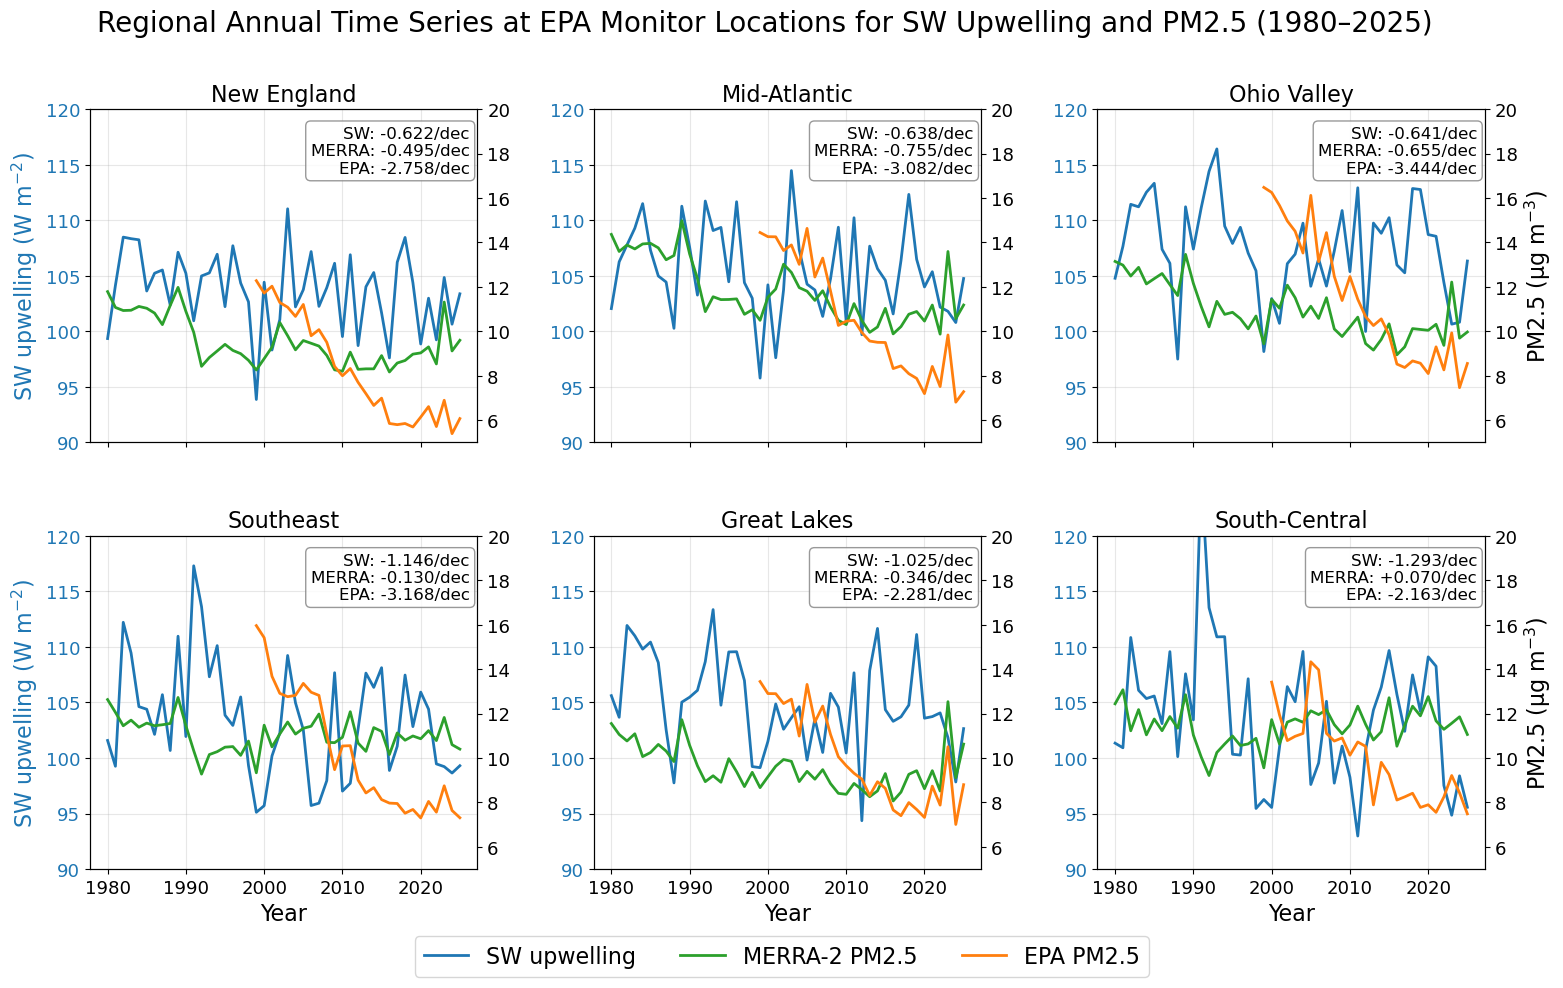

In [3]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import geopandas as gpd

# -----------------------------
# File paths
# -----------------------------
flux_file = "/scratch/sjacker2/project_data/merra2_rad_downloads/merra2_toa_upwelling_lw_sw_combined.nc"
pm25_t2m_file = "/scratch/sjacker2/project_data/merra2_pm25_t2m_eastern_us_monthly_fields_DRY.nc"
monitor_file = "/scratch/sjacker2/project_data/monthly_pm25_eastern_us_1999_2025.csv"
states_shp = "/scratch/sjacker2/project_data/cb_2018_us_state_500k.shp"

# -----------------------------
# Region definitions
# -----------------------------
REGIONS = {
    "New England": [
        "Connecticut", "Maine", "Massachusetts", "New Hampshire", "Rhode Island", "Vermont"
    ],
    "Mid-Atlantic": [
        "New Jersey", "New York", "Pennsylvania", "Delaware", "Maryland", "Virginia"
    ],
    "Ohio Valley": [
        "Indiana", "Kentucky", "Ohio", "West Virginia", "Tennessee
    ],
    "Southeast": [
        "Alabama", "Florida", "Georgia", "Mississippi",
        "North Carolina", "South Carolina", "Arkansas", "Louisiana", "Missouri"
    ],
    "Great Lakes": [
        "Michigan", "Wisconsin", "Illinois"
    ],
}

REGION_ORDER = [
    "New England",
    "Mid-Atlantic",
    "Ohio Valley",
    "Southeast",
    "Great Lakes",
]

STATE_TO_REGION = {
    state: region for region, states in REGIONS.items() for state in states
}

STATE_ABBR_TO_NAME = {
    "AL": "Alabama", "AR": "Arkansas", "CT": "Connecticut", "DE": "Delaware",
    "FL": "Florida", "GA": "Georgia", "IL": "Illinois", "IN": "Indiana",
    "KY": "Kentucky", "LA": "Louisiana", "ME": "Maine", "MA": "Massachusetts",
    "MI": "Michigan", "MS": "Mississippi", "MO": "Missouri", "NH": "New Hampshire",
    "NJ": "New Jersey", "NY": "New York", "NC": "North Carolina", "OH": "Ohio",
    "OK": "Oklahoma", "PA": "Pennsylvania", "RI": "Rhode Island",
    "SC": "South Carolina", "TN": "Tennessee", "TX": "Texas", "VT": "Vermont",
    "VA": "Virginia", "WV": "West Virginia", "WI": "Wisconsin"
}

STATE_FIPS_TO_NAME = {
    1: "Alabama", 5: "Arkansas", 9: "Connecticut", 10: "Delaware",
    12: "Florida", 13: "Georgia", 17: "Illinois", 18: "Indiana",
    21: "Kentucky", 22: "Louisiana", 23: "Maine", 25: "Massachusetts",
    26: "Michigan", 28: "Mississippi", 29: "Missouri", 33: "New Hampshire",
    34: "New Jersey", 36: "New York", 37: "North Carolina", 39: "Ohio",
    40: "Oklahoma", 42: "Pennsylvania", 44: "Rhode Island", 45: "South Carolina",
    47: "Tennessee", 48: "Texas", 50: "Vermont", 51: "Virginia",
    54: "West Virginia", 55: "Wisconsin"
}

# -----------------------------
# Helpers
# -----------------------------
def load_us_states_gdf(shp_path):
    states = gpd.read_file(shp_path).to_crs("EPSG:4326")
    if "NAME" not in states.columns:
        raise ValueError("Could not find NAME column in state shapefile.")
    states = states[states["NAME"].isin(STATE_TO_REGION.keys())].copy()
    states["state_name"] = states["NAME"]
    states["region"] = states["state_name"].map(STATE_TO_REGION)
    return states[["state_name", "region", "geometry"]]


def build_region_masks(lon, lat, states_gdf):
    lon2d, lat2d = np.meshgrid(lon.values, lat.values)

    grid = gpd.GeoDataFrame(
        {"lon": lon2d.ravel(), "lat": lat2d.ravel()},
        geometry=gpd.points_from_xy(lon2d.ravel(), lat2d.ravel()),
        crs="EPSG:4326"
    )

    joined = gpd.sjoin(
        grid,
        states_gdf[["region", "geometry"]],
        how="left",
        predicate="within"
    )

    masks = {}
    for region in REGION_ORDER:
        mask = joined["region"].eq(region).values.reshape(len(lat), len(lon))
        masks[region] = xr.DataArray(
            mask,
            coords={"lat": lat, "lon": lon},
            dims=("lat", "lon")
        )
    return masks


def get_edges_from_centers(centers):
    centers = np.asarray(centers)
    edges = np.zeros(len(centers) + 1)
    edges[1:-1] = 0.5 * (centers[:-1] + centers[1:])
    edges[0] = centers[0] - 0.5 * (centers[1] - centers[0])
    edges[-1] = centers[-1] + 0.5 * (centers[-1] - centers[-2])
    return edges


def assign_monitors_to_grid(monitors, lats, lons):
    lat_edges = get_edges_from_centers(lats)
    lon_edges = get_edges_from_centers(lons)

    lat_idx = np.digitize(monitors["Latitude"].values, lat_edges) - 1
    lon_idx = np.digitize(monitors["Longitude"].values, lon_edges) - 1

    monitors = monitors.copy()
    monitors["lat_idx"] = lat_idx
    monitors["lon_idx"] = lon_idx

    monitors = monitors[
        (monitors["lat_idx"] >= 0) &
        (monitors["lat_idx"] < len(lats)) &
        (monitors["lon_idx"] >= 0) &
        (monitors["lon_idx"] < len(lons))
    ].copy()

    monitors["grid_lat"] = lats[monitors["lat_idx"].values]
    monitors["grid_lon"] = lons[monitors["lon_idx"].values]
    return monitors


def build_monitor_cell_mask(lon, lat, monitor_df):
    lats = lat.values
    lons = lon.values

    mon_locs = monitor_df[["monitor_id", "Latitude", "Longitude"]].drop_duplicates().reset_index(drop=True)
    mon_for_grid = mon_locs.copy()

    if np.nanmax(lons) > 180:
        mon_for_grid["Longitude"] = mon_for_grid["Longitude"] % 360

    mon_grid = assign_monitors_to_grid(mon_for_grid, lats, lons)

    unique_cells = (
        mon_grid[["lat_idx", "lon_idx"]]
        .drop_duplicates()
        .reset_index(drop=True)
    )

    mask = xr.zeros_like(
        xr.DataArray(
            np.zeros((len(lat), len(lon)), dtype=bool),
            coords={"lat": lat, "lon": lon},
            dims=("lat", "lon")
        ),
        dtype=bool
    )

    for _, row in unique_cells.iterrows():
        mask.values[int(row["lat_idx"]), int(row["lon_idx"])] = True

    return mask, mon_grid, unique_cells


def regional_weighted_mean_timeseries(da_3d, combined_mask_2d):
    weights = np.cos(np.deg2rad(da_3d["lat"]))
    masked = da_3d.where(combined_mask_2d)
    return masked.weighted(weights).mean(dim=("lat", "lon"))


def annualize_xr_timeseries(ts):
    return ts.groupby("time.year").mean()


def fit_trend_line(years, values):
    years = np.asarray(years, dtype=float)
    values = np.asarray(values, dtype=float)

    mask = np.isfinite(years) & np.isfinite(values)
    if mask.sum() < 2:
        return np.full_like(years, np.nan, dtype=float), np.nan

    coeffs = np.polyfit(years[mask], values[mask], 1)
    trendline = np.polyval(coeffs, years)
    return trendline, coeffs[0] * 10.0


def detect_monitor_state_column(df):
    for col in ["state_name", "state", "State Name", "state_full"]:
        if col in df.columns:
            return col, "name"
    for col in ["state_abbr", "state_code", "state_postal", "State Code"]:
        if col in df.columns:
            return col, "abbr"
    for col in ["state_fips", "State FIPS", "STATEFP", "statefp"]:
        if col in df.columns:
            return col, "fips"
    return None, None


def assign_monitor_regions(mon):
    state_col, state_kind = detect_monitor_state_column(mon)

    if state_col is None:
        raise ValueError(
            "Could not find a state column in the monitor CSV. "
            "Add one of: state_name/state, state_abbr/state_code, or state_fips."
        )

    if state_kind == "name":
        mon["state_name_std"] = mon[state_col].astype(str).str.strip()
    elif state_kind == "abbr":
        mon["state_name_std"] = (
            mon[state_col].astype(str).str.strip().str.upper().map(STATE_ABBR_TO_NAME)
        )
    elif state_kind == "fips":
        mon["state_name_std"] = pd.to_numeric(mon[state_col], errors="coerce").map(STATE_FIPS_TO_NAME)

    mon["region"] = mon["state_name_std"].map(STATE_TO_REGION)
    mon = mon.dropna(subset=["region"]).copy()
    return mon


def monitor_region_annual_series(mon, region):
    tmp = mon[mon["region"] == region].copy()

    monthly_region = (
        tmp.groupby(["year", "month"], as_index=False)
        .agg(epa_pm25=("monthly_pm25_mean", "mean"))
    )

    annual_region = (
        monthly_region.groupby("year", as_index=False)
        .agg(epa_pm25=("epa_pm25", "mean"))
    )

    full_years = pd.DataFrame({"year": np.arange(1980, 2026)})
    annual_region = full_years.merge(annual_region, on="year", how="left")

    return annual_region


# -----------------------------
# Read and process EPA monitor data
# -----------------------------
mon = pd.read_csv(monitor_file)
mon.columns = mon.columns.str.strip()

for col in ["Latitude", "Longitude", "year", "month", "monthly_pm25_mean"]:
    if col in mon.columns:
        mon[col] = pd.to_numeric(mon[col], errors="coerce")

mon = mon.dropna(subset=["Latitude", "Longitude", "year", "month", "monthly_pm25_mean"]).copy()

if "monitor_id" not in mon.columns:
    mon["monitor_id"] = (
        mon["State Code"].astype(str).str.zfill(2) + "-" +
        mon["County Code"].astype(str).str.zfill(3) + "-" +
        mon["Site Num"].astype(str).str.zfill(4) + "-" +
        mon["POC"].astype(str)
    )

mon["year"] = mon["year"].astype(int)
mon["month"] = mon["month"].astype(int)

MIN_DAILY_VALUES = 1
if "n_daily_values" in mon.columns:
    mon = mon[mon["n_daily_values"] >= MIN_DAILY_VALUES].copy()

mon = assign_monitor_regions(mon)

# -----------------------------
# Load datasets
# -----------------------------
ds_flux = xr.open_dataset(flux_file)
ds_pm = xr.open_dataset(pm25_t2m_file)

ds_flux = ds_flux.sel(time=slice("1980-01-01", "2025-12-31"))
ds_pm = ds_pm.sel(time=slice("1980-01-01", "2025-12-31"))

# -----------------------------
# Build masks
# -----------------------------
states_gdf = load_us_states_gdf(states_shp)
region_masks = build_region_masks(ds_flux["lon"], ds_flux["lat"], states_gdf)

monitor_cell_mask, monitor_grid, unique_cells = build_monitor_cell_mask(
    ds_flux["lon"], ds_flux["lat"], mon
)

print(f"Unique EPA monitors used: {mon['monitor_id'].nunique():,}")
print(f"Unique MERRA-2 grid cells containing monitors: {len(unique_cells):,}")

# -----------------------------
# Build annual regional series using ONLY monitor cells
# -----------------------------
years = np.arange(1980, 2026)
regional_series = {}

for region in REGION_ORDER:
    combined_mask = region_masks[region] & monitor_cell_mask

    sw_ts = regional_weighted_mean_timeseries(ds_flux["TOA_SW_UP"], combined_mask)
    merra_pm25_ts = regional_weighted_mean_timeseries(ds_pm["PM25_dry"], combined_mask)

    sw_annual = annualize_xr_timeseries(sw_ts)
    merra_pm25_annual = annualize_xr_timeseries(merra_pm25_ts)

    sw_series = pd.Series(
        sw_annual.values,
        index=sw_annual["year"].values.astype(int)
    ).reindex(years)

    merra_series = pd.Series(
        merra_pm25_annual.values,
        index=merra_pm25_annual["year"].values.astype(int)
    ).reindex(years)

    regional_series[region] = {
        "SW_up": sw_series,
        "MERRA_PM25": merra_series,
    }

# -----------------------------
# EPA annual series by region
# -----------------------------
for region in REGION_ORDER:
    epa_annual = monitor_region_annual_series(mon, region)
    epa_series = pd.Series(
        epa_annual["epa_pm25"].values,
        index=epa_annual["year"].values.astype(int)
    ).reindex(years)
    regional_series[region]["EPA_PM25"] = epa_series

# -----------------------------
# Plot: one panel per region
# -----------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True)
axes = axes.flatten()

sw_color = "tab:blue"
merra_color = "tab:green"
epa_color = "tab:orange"

legend_handles = None

for i, region in enumerate(REGION_ORDER):
    ax = axes[i]
    axr = ax.twinx()

    sw_vals = regional_series[region]["SW_up"].values
    merra_vals = regional_series[region]["MERRA_PM25"].values
    epa_vals = regional_series[region]["EPA_PM25"].values

    # main lines
    sw_line = ax.plot(years, sw_vals, color=sw_color, linewidth=2, label="SW upwelling")
    merra_line = axr.plot(years, merra_vals, color=merra_color, linewidth=2, label="MERRA-2 PM2.5")
    epa_line = axr.plot(years, epa_vals, color=epa_color, linewidth=2, label="EPA PM2.5")

    # trend lines
    sw_trend, sw_trend_dec = fit_trend_line(years, sw_vals)
    merra_trend, merra_trend_dec = fit_trend_line(years, merra_vals)
    epa_trend, epa_trend_dec = fit_trend_line(years, epa_vals)

    #ax.plot(years, sw_trend, color=sw_color, linestyle="--", linewidth=2)
    #axr.plot(years, merra_trend, color=merra_color, linestyle="--", linewidth=2)
    #axr.plot(years, epa_trend, color=epa_color, linestyle="--", linewidth=2)

    ax.set_title(region, fontsize=16)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", labelsize=13)
    ax.tick_params(axis="y", labelsize=13, labelcolor=sw_color)
    axr.tick_params(axis="y", labelsize=13)

    axr.set_ylim(5, 20)
    ax.set_ylim(90, 120)

    if i in [0, 3]:
        ax.set_ylabel("SW upwelling (W m$^{-2}$)", fontsize=16, color=sw_color)

    if i in [2, 5]:
        axr.set_ylabel("PM2.5 (µg m$^{-3}$)", fontsize=16)

    if i in [3, 4, 5]:
        ax.set_xlabel("Year", fontsize=16)

    trend_text = (
        f"SW: {sw_trend_dec:+.3f}/dec\n"
        f"MERRA: {merra_trend_dec:+.3f}/dec\n"
        f"EPA: {epa_trend_dec:+.3f}/dec"
    )
    ax.text(
        0.98, 0.8, trend_text,
        transform=ax.transAxes,
        ha="right", va="bottom",
        fontsize=12,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="gray")
    )

    if legend_handles is None:
        legend_handles = [sw_line[0], merra_line[0], epa_line[0]]

fig.legend(
    legend_handles,
    ["SW upwelling", "MERRA-2 PM2.5", "EPA PM2.5"],
    loc="lower center",
    ncol=3,
    frameon=True,
    fontsize=16
)

plt.subplots_adjust(bottom=0.12, wspace=0.30, hspace=0.28)
plt.suptitle("Regional Annual Time Series at EPA Monitor Locations for SW Upwelling and PM2.5 (1980–2025)", fontsize=20)
plt.show()

Unique EPA monitors used: 2,103
Unique MERRA-2 grid cells containing monitors: 340


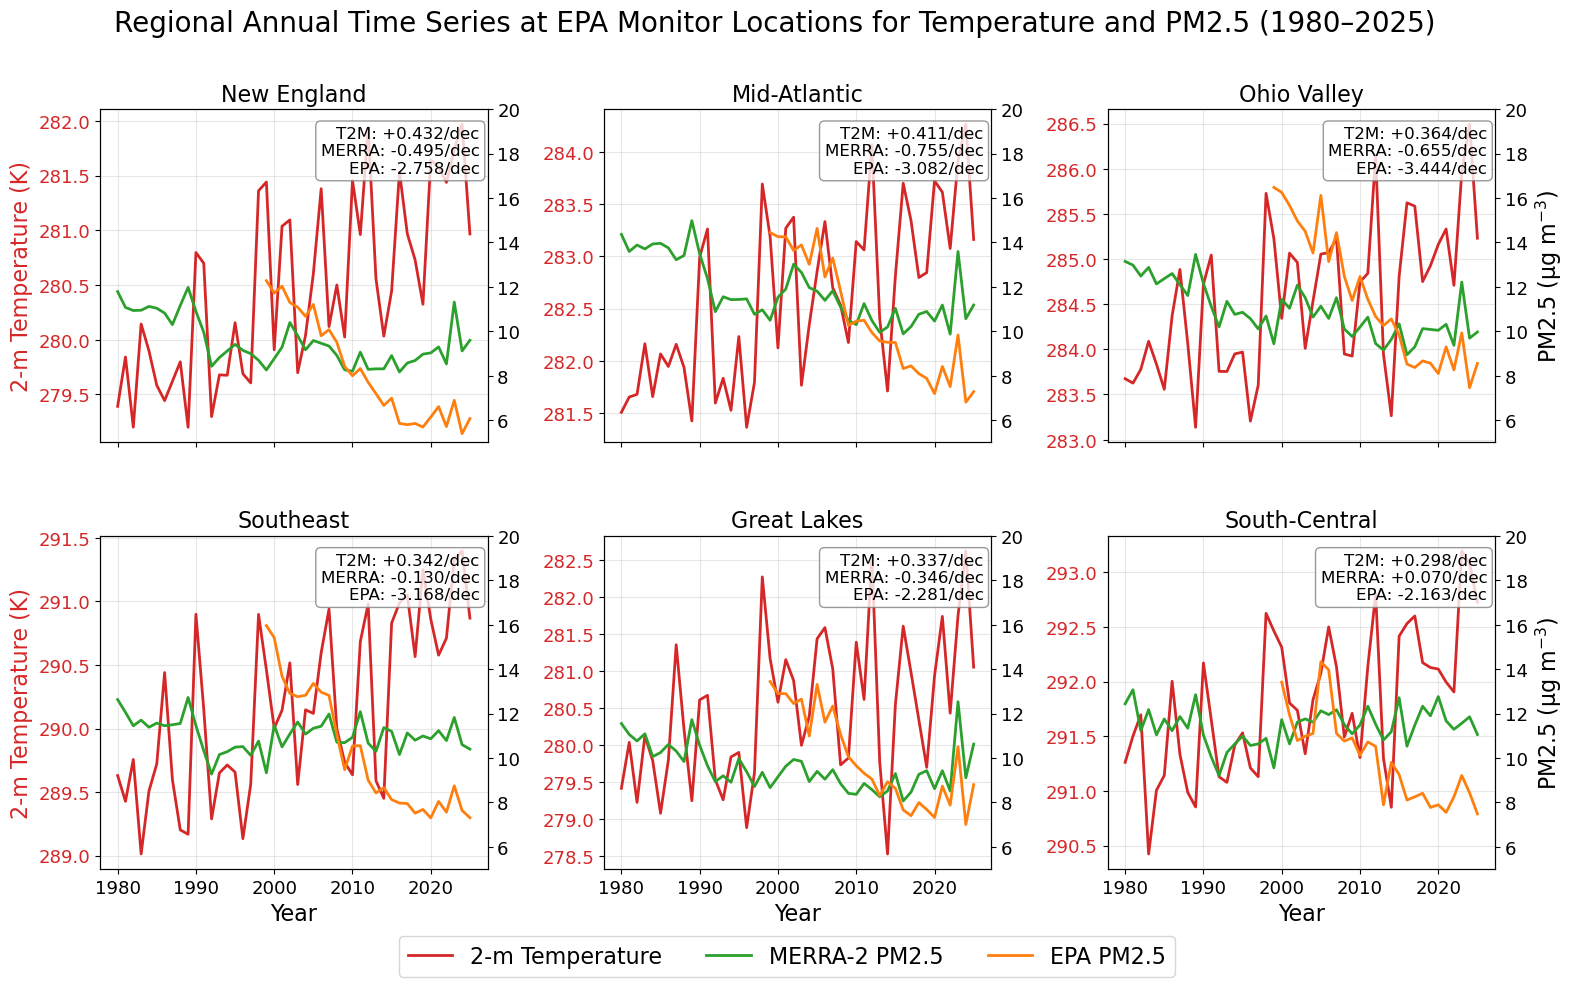

In [5]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import geopandas as gpd

# -----------------------------
# File paths
# -----------------------------
flux_file = "/scratch/sjacker2/project_data/merra2_rad_downloads/merra2_toa_upwelling_lw_sw_combined.nc"
pm25_t2m_file = "/scratch/sjacker2/project_data/merra2_pm25_t2m_eastern_us_monthly_fields_DRY.nc"
monitor_file = "/scratch/sjacker2/project_data/monthly_pm25_eastern_us_1999_2025.csv"
states_shp = "/scratch/sjacker2/project_data/cb_2018_us_state_500k.shp"

# -----------------------------
# Region definitions
# -----------------------------
REGIONS = {
    "New England": [
        "Connecticut", "Maine", "Massachusetts", "New Hampshire", "Rhode Island", "Vermont"
    ],
    "Mid-Atlantic": [
        "New Jersey", "New York", "Pennsylvania", "Delaware", "Maryland", "Virginia"
    ],
    "Ohio Valley": [
        "Indiana", "Kentucky", "Ohio", "West Virginia", "Tennessee
    ],
    "Southeast": [
        "Alabama", "Florida", "Georgia", "Mississippi",
        "North Carolina", "South Carolina", "Arkansas", "Louisiana", "Missouri"
    ],
    "Great Lakes": [
        "Michigan", "Wisconsin", "Illinois"
    ],
}

REGION_ORDER = [
    "New England",
    "Mid-Atlantic",
    "Ohio Valley",
    "Southeast",
    "Great Lakes",
]

STATE_TO_REGION = {
    state: region for region, states in REGIONS.items() for state in states
}

STATE_ABBR_TO_NAME = {
    "AL": "Alabama", "AR": "Arkansas", "CT": "Connecticut", "DE": "Delaware",
    "FL": "Florida", "GA": "Georgia", "IL": "Illinois", "IN": "Indiana",
    "KY": "Kentucky", "LA": "Louisiana", "ME": "Maine", "MA": "Massachusetts",
    "MI": "Michigan", "MS": "Mississippi", "MO": "Missouri", "NH": "New Hampshire",
    "NJ": "New Jersey", "NY": "New York", "NC": "North Carolina", "OH": "Ohio",
    "OK": "Oklahoma", "PA": "Pennsylvania", "RI": "Rhode Island",
    "SC": "South Carolina", "TN": "Tennessee", "TX": "Texas", "VT": "Vermont",
    "VA": "Virginia", "WV": "West Virginia", "WI": "Wisconsin"
}

STATE_FIPS_TO_NAME = {
    1: "Alabama", 5: "Arkansas", 9: "Connecticut", 10: "Delaware",
    12: "Florida", 13: "Georgia", 17: "Illinois", 18: "Indiana",
    21: "Kentucky", 22: "Louisiana", 23: "Maine", 25: "Massachusetts",
    26: "Michigan", 28: "Mississippi", 29: "Missouri", 33: "New Hampshire",
    34: "New Jersey", 36: "New York", 37: "North Carolina", 39: "Ohio",
    40: "Oklahoma", 42: "Pennsylvania", 44: "Rhode Island", 45: "South Carolina",
    47: "Tennessee", 48: "Texas", 50: "Vermont", 51: "Virginia",
    54: "West Virginia", 55: "Wisconsin"
}

# -----------------------------
# Helpers
# -----------------------------
def load_us_states_gdf(shp_path):
    states = gpd.read_file(shp_path).to_crs("EPSG:4326")
    if "NAME" not in states.columns:
        raise ValueError("Could not find NAME column in state shapefile.")
    states = states[states["NAME"].isin(STATE_TO_REGION.keys())].copy()
    states["state_name"] = states["NAME"]
    states["region"] = states["state_name"].map(STATE_TO_REGION)
    return states[["state_name", "region", "geometry"]]


def build_region_masks(lon, lat, states_gdf):
    lon2d, lat2d = np.meshgrid(lon.values, lat.values)

    grid = gpd.GeoDataFrame(
        {"lon": lon2d.ravel(), "lat": lat2d.ravel()},
        geometry=gpd.points_from_xy(lon2d.ravel(), lat2d.ravel()),
        crs="EPSG:4326"
    )

    joined = gpd.sjoin(
        grid,
        states_gdf[["region", "geometry"]],
        how="left",
        predicate="within"
    )

    masks = {}
    for region in REGION_ORDER:
        mask = joined["region"].eq(region).values.reshape(len(lat), len(lon))
        masks[region] = xr.DataArray(
            mask,
            coords={"lat": lat, "lon": lon},
            dims=("lat", "lon")
        )
    return masks


def get_edges_from_centers(centers):
    centers = np.asarray(centers)
    edges = np.zeros(len(centers) + 1)
    edges[1:-1] = 0.5 * (centers[:-1] + centers[1:])
    edges[0] = centers[0] - 0.5 * (centers[1] - centers[0])
    edges[-1] = centers[-1] + 0.5 * (centers[-1] - centers[-2])
    return edges


def assign_monitors_to_grid(monitors, lats, lons):
    lat_edges = get_edges_from_centers(lats)
    lon_edges = get_edges_from_centers(lons)

    lat_idx = np.digitize(monitors["Latitude"].values, lat_edges) - 1
    lon_idx = np.digitize(monitors["Longitude"].values, lon_edges) - 1

    monitors = monitors.copy()
    monitors["lat_idx"] = lat_idx
    monitors["lon_idx"] = lon_idx

    monitors = monitors[
        (monitors["lat_idx"] >= 0) &
        (monitors["lat_idx"] < len(lats)) &
        (monitors["lon_idx"] >= 0) &
        (monitors["lon_idx"] < len(lons))
    ].copy()

    monitors["grid_lat"] = lats[monitors["lat_idx"].values]
    monitors["grid_lon"] = lons[monitors["lon_idx"].values]
    return monitors


def build_monitor_cell_mask(lon, lat, monitor_df):
    lats = lat.values
    lons = lon.values

    mon_locs = monitor_df[["monitor_id", "Latitude", "Longitude"]].drop_duplicates().reset_index(drop=True)
    mon_for_grid = mon_locs.copy()

    if np.nanmax(lons) > 180:
        mon_for_grid["Longitude"] = mon_for_grid["Longitude"] % 360

    mon_grid = assign_monitors_to_grid(mon_for_grid, lats, lons)

    unique_cells = (
        mon_grid[["lat_idx", "lon_idx"]]
        .drop_duplicates()
        .reset_index(drop=True)
    )

    mask = xr.zeros_like(
        xr.DataArray(
            np.zeros((len(lat), len(lon)), dtype=bool),
            coords={"lat": lat, "lon": lon},
            dims=("lat", "lon")
        ),
        dtype=bool
    )

    for _, row in unique_cells.iterrows():
        mask.values[int(row["lat_idx"]), int(row["lon_idx"])] = True

    return mask, mon_grid, unique_cells


def regional_weighted_mean_timeseries(da_3d, combined_mask_2d):
    weights = np.cos(np.deg2rad(da_3d["lat"]))
    masked = da_3d.where(combined_mask_2d)
    return masked.weighted(weights).mean(dim=("lat", "lon"))


def annualize_xr_timeseries(ts):
    return ts.groupby("time.year").mean()


def fit_trend_line(years, values):
    years = np.asarray(years, dtype=float)
    values = np.asarray(values, dtype=float)

    mask = np.isfinite(years) & np.isfinite(values)
    if mask.sum() < 2:
        return np.full_like(years, np.nan, dtype=float), np.nan

    coeffs = np.polyfit(years[mask], values[mask], 1)
    trendline = np.polyval(coeffs, years)
    return trendline, coeffs[0] * 10.0


def detect_monitor_state_column(df):
    for col in ["state_name", "state", "State Name", "state_full"]:
        if col in df.columns:
            return col, "name"
    for col in ["state_abbr", "state_code", "state_postal", "State Code"]:
        if col in df.columns:
            return col, "abbr"
    for col in ["state_fips", "State FIPS", "STATEFP", "statefp"]:
        if col in df.columns:
            return col, "fips"
    return None, None


def assign_monitor_regions(mon):
    state_col, state_kind = detect_monitor_state_column(mon)

    if state_col is None:
        raise ValueError(
            "Could not find a state column in the monitor CSV. "
            "Add one of: state_name/state, state_abbr/state_code, or state_fips."
        )

    if state_kind == "name":
        mon["state_name_std"] = mon[state_col].astype(str).str.strip()
    elif state_kind == "abbr":
        mon["state_name_std"] = (
            mon[state_col].astype(str).str.strip().str.upper().map(STATE_ABBR_TO_NAME)
        )
    elif state_kind == "fips":
        mon["state_name_std"] = pd.to_numeric(mon[state_col], errors="coerce").map(STATE_FIPS_TO_NAME)

    mon["region"] = mon["state_name_std"].map(STATE_TO_REGION)
    mon = mon.dropna(subset=["region"]).copy()
    return mon


def monitor_region_annual_series(mon, region):
    tmp = mon[mon["region"] == region].copy()

    monthly_region = (
        tmp.groupby(["year", "month"], as_index=False)
        .agg(epa_pm25=("monthly_pm25_mean", "mean"))
    )

    annual_region = (
        monthly_region.groupby("year", as_index=False)
        .agg(epa_pm25=("epa_pm25", "mean"))
    )

    full_years = pd.DataFrame({"year": np.arange(1980, 2026)})
    annual_region = full_years.merge(annual_region, on="year", how="left")

    return annual_region


# -----------------------------
# Read and process EPA monitor data
# -----------------------------
mon = pd.read_csv(monitor_file)
mon.columns = mon.columns.str.strip()

for col in ["Latitude", "Longitude", "year", "month", "monthly_pm25_mean"]:
    if col in mon.columns:
        mon[col] = pd.to_numeric(mon[col], errors="coerce")

mon = mon.dropna(subset=["Latitude", "Longitude", "year", "month", "monthly_pm25_mean"]).copy()

if "monitor_id" not in mon.columns:
    mon["monitor_id"] = (
        mon["State Code"].astype(str).str.zfill(2) + "-" +
        mon["County Code"].astype(str).str.zfill(3) + "-" +
        mon["Site Num"].astype(str).str.zfill(4) + "-" +
        mon["POC"].astype(str)
    )

mon["year"] = mon["year"].astype(int)
mon["month"] = mon["month"].astype(int)

MIN_DAILY_VALUES = 1
if "n_daily_values" in mon.columns:
    mon = mon[mon["n_daily_values"] >= MIN_DAILY_VALUES].copy()

mon = assign_monitor_regions(mon)

# -----------------------------
# Load datasets
# -----------------------------
ds_flux = xr.open_dataset(flux_file)
ds_pm = xr.open_dataset(pm25_t2m_file)

ds_flux = ds_flux.sel(time=slice("1980-01-01", "2025-12-31"))
ds_pm = ds_pm.sel(time=slice("1980-01-01", "2025-12-31"))

# -----------------------------
# Build masks
# -----------------------------
states_gdf = load_us_states_gdf(states_shp)
region_masks = build_region_masks(ds_flux["lon"], ds_flux["lat"], states_gdf)

monitor_cell_mask, monitor_grid, unique_cells = build_monitor_cell_mask(
    ds_flux["lon"], ds_flux["lat"], mon
)

print(f"Unique EPA monitors used: {mon['monitor_id'].nunique():,}")
print(f"Unique MERRA-2 grid cells containing monitors: {len(unique_cells):,}")

# -----------------------------
# Build annual regional series using ONLY monitor cells
# -----------------------------
years = np.arange(1980, 2026)
regional_series = {}

for region in REGION_ORDER:
    combined_mask = region_masks[region] & monitor_cell_mask

    t2m_ts = regional_weighted_mean_timeseries(ds_pm["T2M"], combined_mask)
    merra_pm25_ts = regional_weighted_mean_timeseries(ds_pm["PM25_dry"], combined_mask)

    t2m_annual = annualize_xr_timeseries(t2m_ts)
    merra_pm25_annual = annualize_xr_timeseries(merra_pm25_ts)

    t2m_series = pd.Series(
        t2m_annual.values,
        index=t2m_annual["year"].values.astype(int)
    ).reindex(years)

    merra_series = pd.Series(
        merra_pm25_annual.values,
        index=merra_pm25_annual["year"].values.astype(int)
    ).reindex(years)

    regional_series[region] = {
        "T2M": t2m_series,
        "MERRA_PM25": merra_series,
    }

# -----------------------------
# EPA annual series by region
# -----------------------------
for region in REGION_ORDER:
    epa_annual = monitor_region_annual_series(mon, region)
    epa_series = pd.Series(
        epa_annual["epa_pm25"].values,
        index=epa_annual["year"].values.astype(int)
    ).reindex(years)
    regional_series[region]["EPA_PM25"] = epa_series

# -----------------------------
# Plot: one panel per region
# -----------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True)
axes = axes.flatten()

t2m_color = "tab:red"
merra_color = "tab:green"
epa_color = "tab:orange"

legend_handles = None

for i, region in enumerate(REGION_ORDER):
    ax = axes[i]
    axr = ax.twinx()

    t2m_vals = regional_series[region]["T2M"].values
    merra_vals = regional_series[region]["MERRA_PM25"].values
    epa_vals = regional_series[region]["EPA_PM25"].values

    # main lines
    t2m_line = ax.plot(years, t2m_vals, color=t2m_color, linewidth=2, label="2-m temperature")
    merra_line = axr.plot(years, merra_vals, color=merra_color, linewidth=2, label="MERRA-2 PM2.5")
    epa_line = axr.plot(years, epa_vals, color=epa_color, linewidth=2, label="EPA PM2.5")

    # trend lines
    t2m_trend, t2m_trend_dec = fit_trend_line(years, t2m_vals)
    merra_trend, merra_trend_dec = fit_trend_line(years, merra_vals)
    epa_trend, epa_trend_dec = fit_trend_line(years, epa_vals)

    # uncomment if you want trend lines drawn
    # ax.plot(years, t2m_trend, color=t2m_color, linestyle="--", linewidth=2)
    # axr.plot(years, merra_trend, color=merra_color, linestyle="--", linewidth=2)
    # axr.plot(years, epa_trend, color=epa_color, linestyle="--", linewidth=2)

    ax.set_title(region, fontsize=16)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", labelsize=13)
    ax.tick_params(axis="y", labelsize=13, labelcolor=t2m_color)
    axr.tick_params(axis="y", labelsize=13)

    axr.set_ylim(5, 20)

    if i in [0, 3]:
        ax.set_ylabel("2-m Temperature (K)", fontsize=16, color=t2m_color)

    if i in [2, 5]:
        axr.set_ylabel("PM2.5 (µg m$^{-3}$)", fontsize=16)

    if i in [3, 4, 5]:
        ax.set_xlabel("Year", fontsize=16)

    trend_text = (
        f"T2M: {t2m_trend_dec:+.3f}/dec\n"
        f"MERRA: {merra_trend_dec:+.3f}/dec\n"
        f"EPA: {epa_trend_dec:+.3f}/dec"
    )
    ax.text(
        0.98, 0.8,
        trend_text,
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=12,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="gray")
    )

    if legend_handles is None:
        legend_handles = [t2m_line[0], merra_line[0], epa_line[0]]

fig.legend(
    legend_handles,
    ["2-m Temperature", "MERRA-2 PM2.5", "EPA PM2.5"],
    loc="lower center",
    ncol=3,
    frameon=True,
    fontsize=16
)

plt.subplots_adjust(bottom=0.12, wspace=0.30, hspace=0.28)
plt.suptitle("Regional Annual Time Series at EPA Monitor Locations for Temperature and PM2.5 (1980–2025)", fontsize=20)
plt.show()